In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & ZERO-WAIT SOP)
# ==============================================================================
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import joblib

pd.options.mode.chained_assignment = None

# --- 1. CERO-ESPERAS (ZERO-WAIT) SOP CONFIG ---
FORCE_UPDATE = False 
DATE_PREFIX  = "260505"
NOTEBOOK_ID  = "0509"

# --- 2. CODESPACES PATHING ---
PROJECT_ROOT = "/workspaces/pienza"
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")
DUMP_DIR     = os.path.join(DATA_DIR, "dumped_files")
DB_PATH      = os.path.join(DATA_DIR, "pienza.db")

os.makedirs(DUMP_DIR, exist_ok=True)

# --- 3. CONNECTIVITY ---
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"✅ SQL Engine Active: {DB_PATH}")

# --- 4. VISUAL CANON ---
OPUS_PURPLE, OPUS_TEAL = '#440154', '#21918c'
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.facecolor': '#FAFAFA', 'axes.facecolor': '#FAFAFA', 'axes.titlecolor': OPUS_PURPLE})

print(f"✅ SOP Cero-Esperas cargado (Notebook {NOTEBOOK_ID}).")
print("\n--- SYSTEM READY FOR CASCADE PRODUCTION ---")

✅ SQL Engine Active: /workspaces/pienza/data/pienza.db
✅ SOP Cero-Esperas cargado (Notebook 0509).

--- SYSTEM READY FOR CASCADE PRODUCTION ---


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (NO PCA - RAW UNIVERSES ONLY)
# ==============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging RAW analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING (NO PCA) ---
print("⚖️ Scaling Universes (StandardScaler only)...")

# UNIVERSO A: The Wide Horizon
scaler_a = StandardScaler()
X_league_a = pd.DataFrame(
    scaler_a.fit_transform(X_a_log),
    index=X_a_log.index,
    columns=X_a_log.columns
)

# UNIVERSO

⏳ Ingesting v_ML_Supervised and forging RAW analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
⚖️ Scaling Universes (StandardScaler only)...


In [3]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [4]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [5]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [6]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


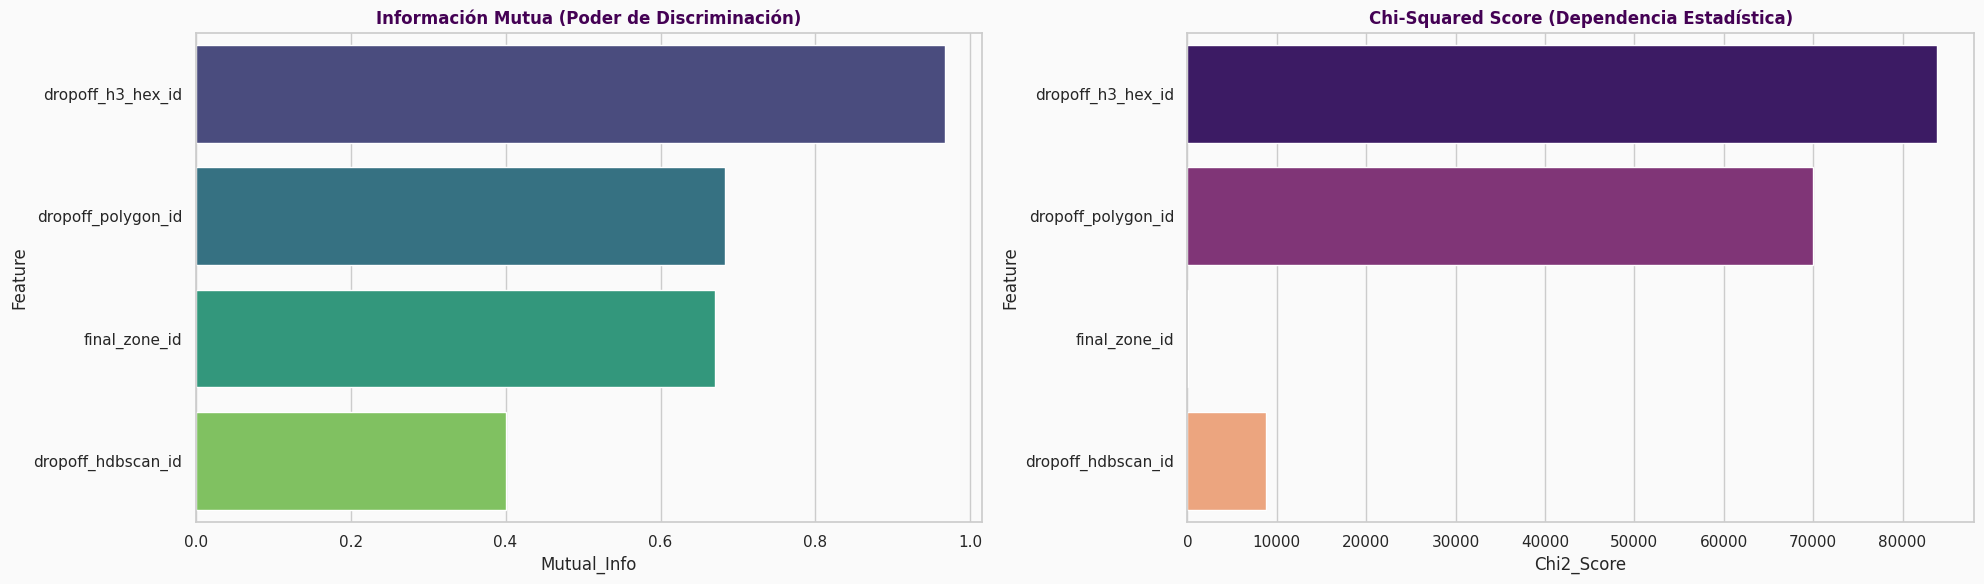

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [7]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [8]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [9]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


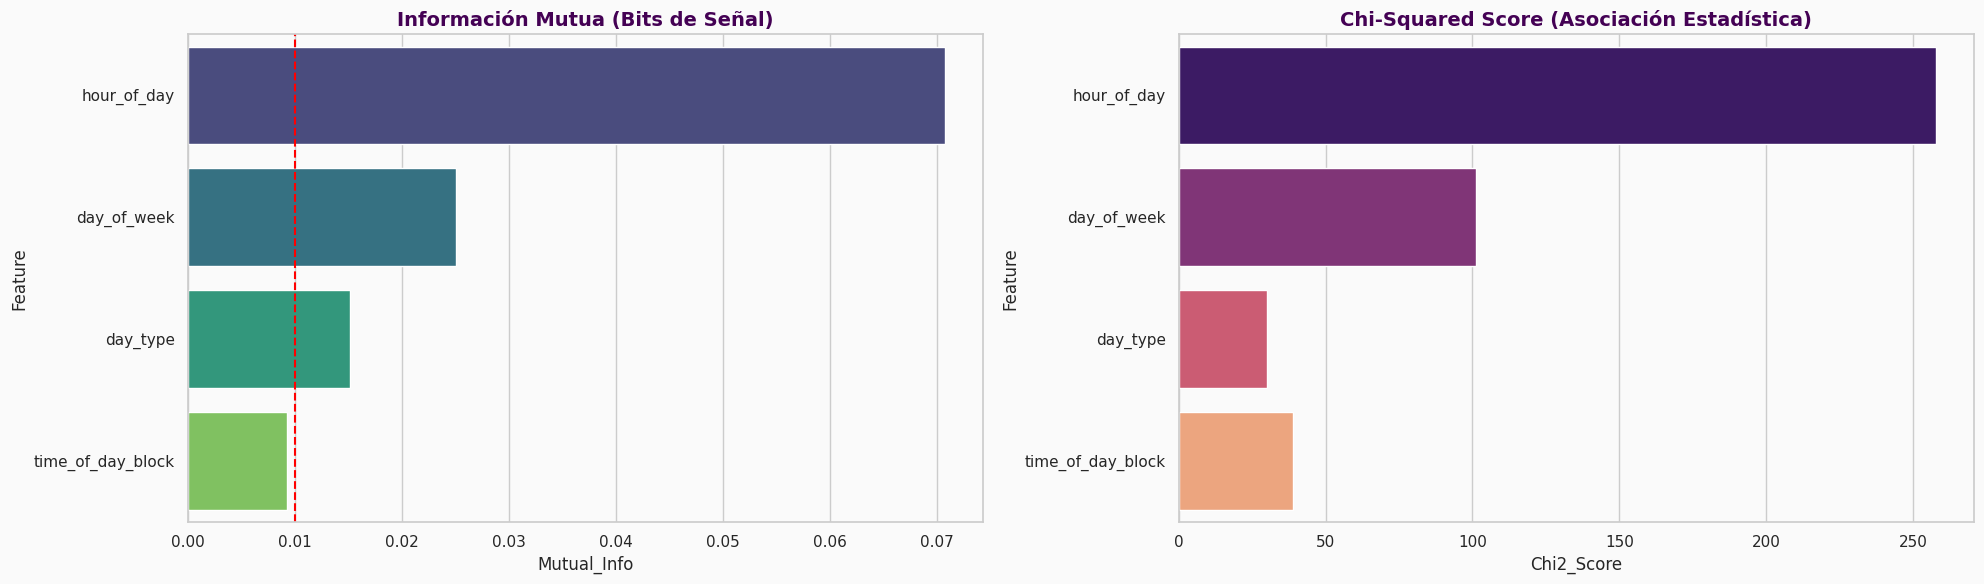

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [10]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 2 features in isolation...


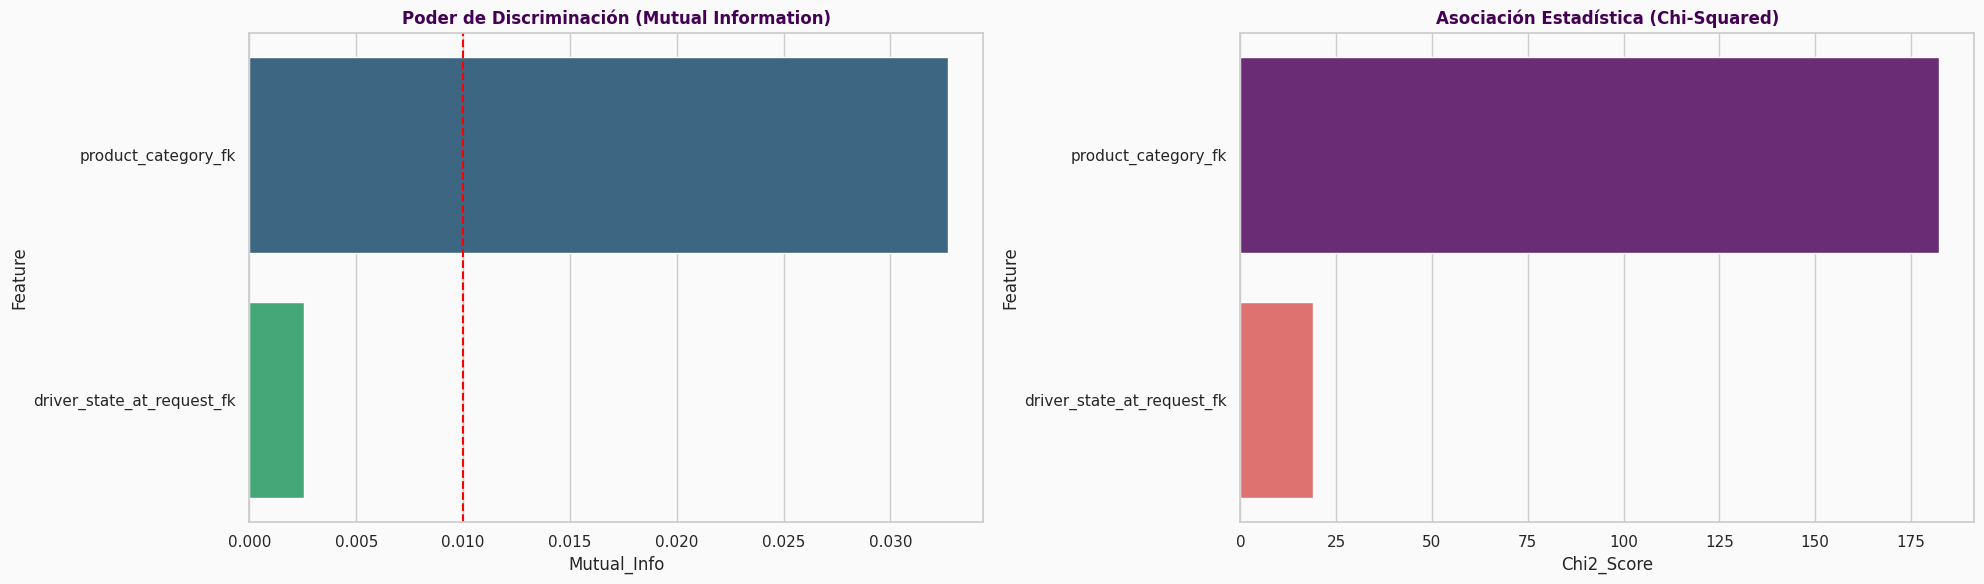

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,product_category_fk,0.032699,182.354377,1.072798e-36
1,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.0327**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [11]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
   # 'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [12]:
# ==============================================================================
# CELL 1.4c (UPDATED): THE HYBRID OHE FUSION (WITH MID-TIER FUSION)
# ==============================================================================
# Purpose: Merge Numerical Universes with Categorical (One-Hot) Features.
# Change:  Fuses 'Comfort' and 'Business Comfort' into a single 'Mid-Tier' signal.
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ Executing Hybrid Fusion (Context Flag Restored & Products Merged)...")

# --- 0. AUTO-REPARACIÓN DE VARIABLES NUMÉRICAS ---
# Si no corriste la Celda 1 nueva, intentamos usar los nombres viejos
if 'X_league_b' not in locals():
    print("⚠️ 'X_league_b' no encontrada. Buscando fallbacks...")
    if 'X_praetorian_final_raw' in locals():
        X_league_b = X_praetorian_final_raw
        print("   ✅ Fallback exitoso: Usando 'X_praetorian_final_raw' como Liga B.")
    elif 'X_b_raw' in locals():
        X_league_b = X_b_raw
        print("   ✅ Fallback exitoso: Usando 'X_b_raw' como Liga B.")
    else:
        raise ValueError("🔴 ERROR CRÍTICO: No se encuentran los datos numéricos (X_league_b). Por favor corre la Celda 1.")

if 'X_league_a' not in locals():
    if 'X_wide_pca' in locals(): # Ojo: si tienes la version vieja con PCA
        X_league_a = X_wide_pca
        print("   ⚠️ Usando versión PCA antigua para Liga A.")
    elif 'X_a_raw' in locals():
        X_league_a = X_a_raw
        print("   ✅ Fallback exitoso: Usando 'X_a_raw' como Liga A.")

# 1. LISTA DE CATEGÓRICOS
candidates = [
    'final_zone_id',
    # 'heuristic_flag_context', # <--- REINCORPORADA O COMENTADA SEGÚN PREFIERAS
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Filtro de seguridad: Solo usamos las que existan en df_input
winning_cats = [c for c in candidates if c in df_input.columns]
print(f"   -> Features Categóricos Confirmados: {winning_cats}")

# --- 1.5 PRODUCT FUSION (THE MID-TIER CREATION) ---
X_cats_final = df_input[winning_cats].copy()

if 'product_category_fk' in X_cats_final.columns:
    print("   -> Fusing 'Comfort' and 'Business Comfort' into 'Mid-Tier'...")
    # Convirtiendo a int si es posible para asegurar un reemplazo limpio
    try:
        X_cats_final['product_category_fk'] = pd.to_numeric(X_cats_final['product_category_fk'], errors='coerce')
        # Asumiendo que 2 = Comfort y 3 = Business Comfort (verifica si tus IDs son diferentes)
        # Reemplazamos el ID 3 por 2, agrupando ambos bajo la categoría "2"
        X_cats_final['product_category_fk'] = X_cats_final['product_category_fk'].replace({3: 2})
    except Exception as e:
        print(f"   ⚠️ Warning in product fusion: {e}")

# 2. ONE-HOT ENCODING
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

X_ohe = pd.get_dummies(X_cats_final, drop_first=True)
print(f"   -> OHE Shape: {X_ohe.shape}")

# 3. FUSIÓN HÍBRIDA (NUM + CAT)
# LIGA A (Wide)
X_league_a_hybrid = pd.concat([X_league_a, X_ohe], axis=1)

# LIGA B (Praetorian)
X_league_b_hybrid = pd.concat([X_league_b, X_ohe], axis=1)

# 4. EMPAQUETADO FINAL
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid
}

print(f"\n✅ UNIVERSOS HÍBRIDOS LISTOS:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: TOURNAMENT ---")

⏳ Executing Hybrid Fusion (Context Flag Restored & Products Merged)...
⚠️ 'X_league_b' no encontrada. Buscando fallbacks...
   ✅ Fallback exitoso: Usando 'X_b_raw' como Liga B.
   -> Features Categóricos Confirmados: ['final_zone_id', 'hour_of_day', 'product_category_fk', 'day_of_week']
   -> Fusing 'Comfort' and 'Business Comfort' into 'Mid-Tier'...
   -> OHE Shape: (4760, 94)

✅ UNIVERSOS HÍBRIDOS LISTOS:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 135)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 114)

--- NEXT STOP: TOURNAMENT ---


In [13]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [14]:
# ==============================================================================
# CELL 1.5 (FIXED): TEMPORAL INDEXING & SYNCHRONIZATION
# ==============================================================================
print("⏳ Synchronizing Temporal Engine (Full Sync Mode)...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0
for wk, start, end in sacred_schedule:
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. FILTER & SYNC (THE FIX)
# Detectamos qué filas son válidas
valid_rows_mask = df_input['week_id'] > 0

print(f"   -> Dropping {len(df_input) - valid_rows_mask.sum()} out-of-schedule rows.")

# APLICAMOS EL FILTRO A TODO SIMULTÁNEAMENTE
df_input = df_input[valid_rows_mask].reset_index(drop=True)
y = y[valid_rows_mask] # <--- CRUCIAL: Sincronizar Target

# Sincronizar Ligas Existentes
# Si ligas_finales ya fue creada en 1.4c, la actualizamos
if 'ligas_finales' in locals():
    for name, df_lig in ligas_finales.items():
        ligas_finales[name] = df_lig[valid_rows_mask].reset_index(drop=True)
        print(f"   -> Synced {name}: {ligas_finales[name].shape}")

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS
custom_cv_folds = []
for i in range(1, 6):
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    test_mask = (df_input['week_id'] == i + 1)
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()
    custom_cv_folds.append((train_indices, test_indices))
    print(f"   -> Fold {i}: Train W[1-{i}] vs Test W{i+1}")

print("\n✅ Temporal Engine Fully Synchronized.")

⏳ Synchronizing Temporal Engine (Full Sync Mode)...
   -> Dropping 0 out-of-schedule rows.
   -> Synced LIGA_A_Wide_Hybrid: (4760, 135)
   -> Synced LIGA_B_Praetorian_Raw_Hybrid: (4760, 114)
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64
   -> Fold 1: Train W[1-1] vs Test W2
   -> Fold 2: Train W[1-2] vs Test W3
   -> Fold 3: Train W[1-3] vs Test W4
   -> Fold 4: Train W[1-4] vs Test W5
   -> Fold 5: Train W[1-5] vs Test W6

✅ Temporal Engine Fully Synchronized.


# Aqui Empieza Cascada Cognitiva Capa 1

In [15]:
# ==============================================================================
# CAPA 1 - CELL 1: THE BOUNCER'S FOUNDRY (TRIAGE DATA PREP)
# ==============================================================================
# Purpose: Create the target and feature matrix for Layer 1 of the Cascade.
#          Target: [Non-Op, Proxy, Low-Profit, Long-Pickup, THE_NUANCED]
# Change:  "Proxy Zone" moved to Layer 1 for immediate filtering.
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import re

print("⏳ Forging Layer 1: The Triage Engine (Proxy Zone Integrated)...")

# 1. DEFINICIÓN DEL TARGET DE CAPA 1 (y_L1)
# Mapeamos la realidad a las 5 puertas del Portero
# IDs Originales: 1:Non-Op, 2:Proxy, 3:Low-Profit, 4:Long-Pickup, 5:DSM, 6:EEUM, 9999:Accept
def map_layer1_target(val):
    if val == 1: return "🔴 Non-Operational"
    if val == 2: return "🔴 Proxy Zone"        # <--- CAMBIO: El Portero ahora filtra Proxies
    if val == 3: return "🔴 Low Profitability"
    if val == 4: return "🔴 Long Pickup"
    # El resto (Accepted, Strategic Mismatch, EEUM) pasan a la Capa 2
    return "💎 THE_NUANCED_REST"

# Creamos la serie limpia
y_L1_text = df_input['reason_primary_fk'].fillna(9999).apply(map_layer1_target)

# Codificamos para el modelo
le_L1 = LabelEncoder()
y_L1 = le_L1.fit_transform(y_L1_text)
print(f"✅ Layer 1 Target Created. Classes: {list(le_L1.classes_)}")

# 2. DEFINICIÓN DE FEATURES (X_L1)
# Basado en la lista ratificada por el Arquitecto
numeric_L1 = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'traffic_index_base_120', 'time_since_last_offer',
    'eph_operational_index', 'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

categorical_L1 = [
    'product_category_fk', 'hour_of_day', 'day_of_week', 'final_zone_id'
]

# A. Procesamiento Numérico
X_num = df_input[numeric_L1].copy()
for col in ['historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml']:
    X_num[col] = pd.to_numeric(X_num[col], errors='coerce')
X_num = X_num.fillna(0)

# B. Procesamiento Categórico (OHE)
X_cat = df_input[categorical_L1].fillna("N/A").astype(str)
# drop_first=True para evitar redundancia
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# 3. FUSIÓN FINAL
X_L1 = pd.concat([X_num, X_cat_encoded], axis=1)

# 4. LIMPIEZA DE NOMBRES PARA XGBOOST
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_L1.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_L1.columns]

print(f"✅ Layer 1 Matrix Forged. Shape: {X_L1.shape}")
print("-" * 60)
print("DISTRIBUCIÓN DE CLASES EN CAPA 1 (Ahora incluye Proxy):")
print(y_L1_text.value_counts(normalize=True))

⏳ Forging Layer 1: The Triage Engine (Proxy Zone Integrated)...
✅ Layer 1 Target Created. Classes: ['💎 THE_NUANCED_REST', '🔴 Long Pickup', '🔴 Low Profitability', '🔴 Non-Operational', '🔴 Proxy Zone']
✅ Layer 1 Matrix Forged. Shape: (4760, 103)
------------------------------------------------------------
DISTRIBUCIÓN DE CLASES EN CAPA 1 (Ahora incluye Proxy):
reason_primary_fk
🔴 Non-Operational      0.497059
💎 THE_NUANCED_REST     0.199790
🔴 Low Profitability    0.176050
🔴 Long Pickup          0.076891
🔴 Proxy Zone           0.050210
Name: proportion, dtype: float64


In [16]:
# ==============================================================================
# CAPA 1 - CELL 2: THE BOUNCER'S TOURNAMENT (STRATIFIED GYM)
# ==============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import numpy as np

print("⏳ Initiating Layer 1 Battle Royale...")
print("   -> Mission: High-Precision Triage (Non-Op, Low-Profit, Long-Pickup)")

# 1. TEMPORAL MASK (Training Pool: Weeks 1-5)
tournament_mask = df_input['week_id'].isin([1, 2, 3, 4, 5])
X_L1_train = X_L1[tournament_mask]
y_L1_train = y_L1[tournament_mask]

print(f"   -> Training Pool: {len(X_L1_train)} samples.")

# 2. WEIGHTED STRATEGY (Combatiendo el desbalance del 7.7%)
# Calculamos pesos balanceados específicos para las 4 clases de la Capa 1
l1_sample_weights = compute_sample_weight(class_weight='balanced', y=y_L1_train)

# 3. SETUP DE VALIDACIÓN (EL GIMNASIO)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# 4. CONFIGURACIÓN DEL MODELO (XGBOOST AGRESIVO)
# Usamos max_depth=6 para capturar las reglas geográficas y económicas complejas
model_L1 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

# 5. EJECUCIÓN DEL TORNEO
print(f"🥊 Training Layer 1 Model...")
cv_results = cross_validate(
    model_L1,
    X_L1_train,
    y_L1_train,
    cv=skf,
    scoring=scoring,
    params={'sample_weight': l1_sample_weights}, # Inyectamos pesos
    n_jobs=-1
)

# 6. REPORTE DE RENDIMIENTO
print("\n" + "="*70)
print("🏆 LAYER 1 PERFORMANCE CARD (STRATIFIED CV)")
print("="*70)
print(f"📊 F1-MACRO:   {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
print(f"🎯 PRECISION:  {cv_results['test_precision_macro'].mean():.4f}")
print(f"📡 RECALL:     {cv_results['test_recall_macro'].mean():.4f}")
print("-" * 70)

# 7. DEFINICIÓN DEL GANADOR PARA TUNING
best_L1_score = cv_results['test_f1_macro'].mean()
print(f"✅ Layer 1 Baseline established at {best_L1_score:.4f}")

⏳ Initiating Layer 1 Battle Royale...
   -> Mission: High-Precision Triage (Non-Op, Low-Profit, Long-Pickup)
   -> Training Pool: 3980 samples.
🥊 Training Layer 1 Model...

🏆 LAYER 1 PERFORMANCE CARD (STRATIFIED CV)
📊 F1-MACRO:   0.7998 (+/- 0.0087)
🎯 PRECISION:  0.7779
📡 RECALL:     0.8322
----------------------------------------------------------------------
✅ Layer 1 Baseline established at 0.7998


In [17]:
# ==============================================================================
# CELL 3 (FIXED): PURGE, SPLIT, AND ISOLATION (CHRONOLOGICAL LOCKDOWN)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...")

# 1. AISLAMIENTO DE LA LIGA GANADORA (LIGA B)
# Usamos 'copy()' para asegurar que es un objeto independiente en memoria
X_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# 2. DEFINICIÓN DEL CORTE TEMPORAL (Semana 6 es Test)
# Requerimos 'week_id' del df_input original para hacer el corte
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR CRÍTICO: No se encuentra 'week_id'. Corre la Celda 1.5 primero.")

CUTOFF_WEEK = 5 # Entrenamos con Semanas 1, 2, 3, 4, 5. Testeamos con 6.

# Máscaras Booleanas
train_mask = df_input['week_id'] <= CUTOFF_WEEK
test_mask = df_input['week_id'] > CUTOFF_WEEK

# 3. SPLIT SAGRADO (CRONOLÓGICO)
# No usamos train_test_split aleatorio. Usamos el tiempo.
X_train = X_final[train_mask]
X_test  = X_final[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# 4. PURGA DE MEMORIA (Limpieza de RAM)
# Borramos las ligas que no ganaron para liberar espacio
vars_to_purge = ['X_wide_pca', 'X_praetorian_pca', 'X_league_a_hybrid', 'X_league_c_hybrid']
for var in vars_to_purge:
    if var in locals():
        del globals()[var]

print("✅ Ligas perdedoras purgadas. RAM liberada.")

# 5. REPORTE DE INTEGRIDAD
print(f"\n✅ Final Dataset Locked (Liga B, Raw Hybrid).")
print(f"   -> Estrategia: Walk-Forward (Train: W1-{CUTOFF_WEEK} | Test: W{CUTOFF_WEEK+1})")
print(f"   -> X_train Shape: {X_train.shape} (Historico)")
print(f"   -> X_test Shape:  {X_test.shape}  (Futuro Inmediato)")

# Verificación de fugas
if len(set(X_train.index).intersection(set(X_test.index))) == 0:
    print("🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.")
else:
    print("⚠️ ALERTA: Hay índices compartidos. Revisa el corte.")

⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...
✅ Ligas perdedoras purgadas. RAM liberada.

✅ Final Dataset Locked (Liga B, Raw Hybrid).
   -> Estrategia: Walk-Forward (Train: W1-5 | Test: W6)
   -> X_train Shape: (3980, 114) (Historico)
   -> X_test Shape:  (780, 114)  (Futuro Inmediato)
🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.


In [18]:
# ==============================================================================
# CAPA 1 - CELL 3: THE BOUNCER'S TUNING (STRATIFIED GYM - SOP READY)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import pandas as pd
import numpy as np
import time
import os
import joblib

# --- SOP PERSISTENCE CONFIG ---
# Usando DATE_PREFIX y NOTEBOOK_ID definidos en tu Cell 0
TUNING_L1_FILE = f"{DATE_PREFIX}_{NOTEBOOK_ID}_tuning_L1.joblib"
TUNING_L1_PATH = os.path.join(DUMP_DIR, TUNING_L1_FILE)

print(f"⏳ INICIANDO/CARGANDO AFINACIÓN ESTRATIFICADA (Notebook {NOTEBOOK_ID})...")

# 1. PREPARACIÓN DE DATOS (SEMANAS 1-5)
X_train_L1 = X_L1[tournament_mask].copy()
y_train_L1 = y_L1[tournament_mask]

# --- LÓGICA LOAD-OR-TRAIN ---
if os.path.exists(TUNING_L1_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando resultados de Tuning L1 desde {TUNING_L1_FILE}...")
    search_L1 = joblib.load(TUNING_L1_PATH)
    model_champion_L1 = search_L1.best_estimator_
else:
    print(f"   -> Datos disponibles para Tuning (W1-5): {len(X_train_L1)} muestras.")

    # 2. ESTRATEGIA DE PESOS
    l1_tuning_weights = compute_sample_weight(class_weight='balanced', y=y_train_L1)

    # 3. ESTRATEGIA DE VALIDACIÓN
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 4. ESPACIO DE BÚSQUEDA
    param_dist = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 5, 6, 7],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.5, 1, 2],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    }

    # 5. CONFIGURACIÓN DEL MOTOR
    xgb_l1 = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    # 6. EJECUCIÓN DE BÚSQUEDA
    search_L1 = RandomizedSearchCV(
        estimator=xgb_l1,
        param_distributions=param_dist,
        n_iter=20,
        scoring='f1_macro',
        cv=skf,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        error_score=0
    )

    start_time = time.time()
    print(f"⚔️ Buscando configuración óptima para Triage en {X_train_L1.shape}...")

    # Inyectamos los pesos en el fit
    search_L1.fit(X_train_L1, y_train_L1, sample_weight=l1_tuning_weights)
    
    elapsed = time.time() - start_time
    
    # Exportación del objeto completo y el campeón
    model_champion_L1 = search_L1.best_estimator_
    joblib.dump(search_L1, TUNING_L1_PATH)
    
    print(f"\n✅ AFINACIÓN DE CAPA 1 COMPLETADA en {elapsed:.1f} segundos.")
    print(f"💾 Resultados guardados en: {TUNING_L1_FILE}")

# 7. RESULTADOS FINALES
print(f"🏆 Mejor Score Validación (F1-Macro): {search_L1.best_score_:.4f}")
print("-" * 60)
print(f"🔑 MEJORES HIPERPARÁMETROS L1:\n{search_L1.best_params_}")
print("-" * 60)
print("✅ Variable 'model_champion_L1' lista para la misión de Triage.")

⏳ INICIANDO/CARGANDO AFINACIÓN ESTRATIFICADA (Notebook 0509)...
📦 SOP: Cargando resultados de Tuning L1 desde 260505_0509_tuning_L1.joblib...
🏆 Mejor Score Validación (F1-Macro): 0.8361
------------------------------------------------------------
🔑 MEJORES HIPERPARÁMETROS L1:
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}
------------------------------------------------------------
✅ Variable 'model_champion_L1' lista para la misión de Triage.


⏳ INICIANDO/CARGANDO VALIDACIÓN (Notebook 0509)...
📦 SOP: Cargando scores de validación desde 260505_0509_val_curve_L1.parquet...


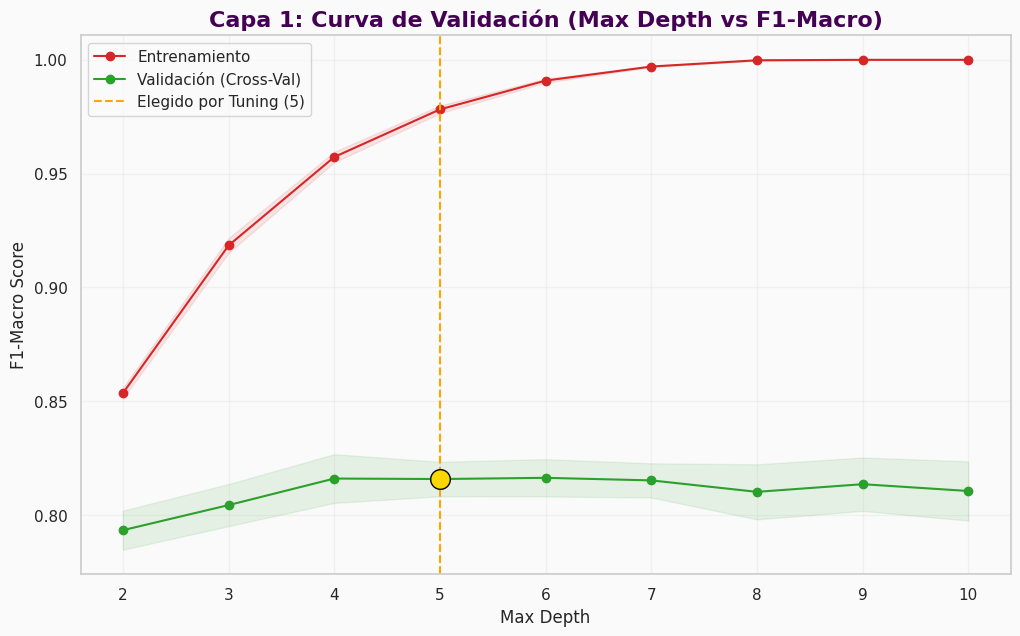

📊 Análisis de Brecha en Depth=5: 0.1624


In [19]:
# ==============================================================================
# CAPA 1 - CELL 4 (ROBUST): THE BOUNCER'S VALIDATION (OCKHAM AUDIT - SOP READY)
# ==============================================================================
from sklearn.model_selection import validation_curve
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# --- SOP PERSISTENCE CONFIG ---
VAL_CURVE_FILE = f"{DATE_PREFIX}_{NOTEBOOK_ID}_val_curve_L1.parquet"
VAL_CURVE_PATH = os.path.join(DUMP_DIR, VAL_CURVE_FILE)

print(f"⏳ INICIANDO/CARGANDO VALIDACIÓN (Notebook {NOTEBOOK_ID})...")

# 1. SETUP DE PARÁMETROS
param_range = np.arange(2, 11) # Probaremos profundidades de 2 a 10

# --- LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(VAL_CURVE_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando scores de validación desde {VAL_CURVE_FILE}...")
    df_scores = pd.read_parquet(VAL_CURVE_PATH)
    # Re-seccionamos las matrices originales
    train_scores = df_scores[[c for c in df_scores.columns if 'train' in c]].values
    test_scores  = df_scores[[c for c in df_scores.columns if 'test' in c]].values
else:
    print("⏳ Calculating Validation Curve with Sample Weights (Manual Mode)...")
    
    best_params = search_L1.best_params_.copy()
    if 'max_depth' in best_params:
        del best_params['max_depth']

    model_audit = xgb.XGBClassifier(
        **best_params,
        objective='multi:softprob',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

    # 2. CÁLCULO DE LA CURVA (Scikit-learn nativo)
    train_scores, test_scores = validation_curve(
        model_audit,
        X_train_L1,
        y_train_L1,
        param_name="max_depth",
        param_range=param_range,
        cv=skf,
        scoring="f1_macro",
        n_jobs=-1,
        params={'sample_weight': l1_tuning_weights} # <--- INYECCIÓN DE PESOS
    )
    
    # Persistencia SOP en formato Parquet
    df_scores = pd.concat([
        pd.DataFrame(train_scores, columns=[f'train_{i}' for i in range(train_scores.shape[1])]),
        pd.DataFrame(test_scores, columns=[f'test_{i}' for i in range(test_scores.shape[1])])
    ], axis=1)
    df_scores.to_parquet(VAL_CURVE_PATH)
    print(f"✅ Validación completada y guardada en {VAL_CURVE_FILE}")

# 3. PROMEDIOS Y DESVIACIÓN
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. VISUALIZACIÓN (OPUS LAB STYLE)
plt.figure(figsize=(12, 7))

# Curva de Entrenamiento
plt.plot(param_range, train_mean, label="Entrenamiento", color="#d62728", marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")

# Curva de Validación
plt.plot(param_range, test_mean, label="Validación (Cross-Val)", color="#2ca02c", marker='o')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")

# Marcar el punto elegido (Max Depth = 5)
plt.axvline(x=5, color='orange', linestyle='--', label='Elegido por Tuning (5)')
plt.scatter(5, test_mean[param_range == 5], s=200, color='gold', edgecolor='black', zorder=5)

plt.title("Capa 1: Curva de Validación (Max Depth vs F1-Macro)", fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Max Depth")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.2)
plt.show()

# 5. DIAGNÓSTICO
print(f"📊 Análisis de Brecha en Depth=5: {train_mean[param_range==5][0] - test_mean[param_range==5][0]:.4f}")

In [20]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT & IMMUTABLE INDEXING (LAYER 1)
# ==============================================================================
# Purpose: Lock the relationship between Model Indices and Strategic Categories.
#          Prevents "Dancing Index" bugs in custom threshold logic.
# ==============================================================================
import pandas as pd
import numpy as np

print("🕵️‍♂️ AUDITING LAYER 1: THE TRIAGE TRUTH SERUM...")
print("-" * 80)

# 1. Recuperar el orden alfabético que el LabelEncoder impuso
l1_classes = le_L1.classes_

# 2. CREACIÓN DE ÍNDICES INMUTABLES (Para uso en Celdas de Umbrales)
# En lugar de usar '2', usaremos estas variables que siempre apuntarán a lo correcto
try:
    IDX_NUANCED    = np.where(l1_classes == "💎 THE_NUANCED_REST")[0][0]
    IDX_LONG_PICK  = np.where(l1_classes == "🔴 Long Pickup")[0][0]
    IDX_LOW_PROFIT = np.where(l1_classes == "🔴 Low Profitability")[0][0]
    IDX_NON_OP     = np.where(l1_classes == "🔴 Non-Operational")[0][0]

    print("✅ Estatus: Índices estratégicos mapeados y bloqueados.")
except IndexError as e:
    print(f"🔴 ERROR: Una de las clases estratégicas no se encontró en le_L1.classes_: {e}")

# 3. REPORTE VISUAL DE VERDAD
audit_data = []
for i, name in enumerate(l1_classes):
    count = np.sum(y_L1 == i)
    audit_data.append({
        "Model Index": i,
        "Variable Global": f"IDX_...", # Placeholder visual
        "Strategic Category": name,
        "Samples (N)": count
    })

df_l1_audit = pd.DataFrame(audit_data)
display(df_l1_audit)

print("-" * 80)
print(f"🚀 CONTROL DE ACCESO: La puerta a la Capa 2 es el Índice [{IDX_NUANCED}].")

🕵️‍♂️ AUDITING LAYER 1: THE TRIAGE TRUTH SERUM...
--------------------------------------------------------------------------------
✅ Estatus: Índices estratégicos mapeados y bloqueados.


,Model Index,Variable Global,Strategic Category,Samples (N)
0,0,IDX_...,💎 THE_NUANCED_REST,951
1,1,IDX_...,🔴 Long Pickup,366
2,2,IDX_...,🔴 Low Profitability,838
3,3,IDX_...,🔴 Non-Operational,2366
4,4,IDX_...,🔴 Proxy Zone,239


--------------------------------------------------------------------------------
🚀 CONTROL DE ACCESO: La puerta a la Capa 2 es el Índice [0].


⏳ PHASE 3: Executing Layer 1 Final Exam (The Bouncer's Trial)...
   -> Testing on Week 6: 780 samples.

📋 LAYER 1: CLASSIFICATION REPORT (The Bouncer's Performance)
                     precision    recall  f1-score   support

 💎 THE_NUANCED_REST       0.74      0.68      0.71       164
      🔴 Long Pickup       0.52      0.95      0.68        56
🔴 Low Profitability       0.71      0.78      0.74       128
  🔴 Non-Operational       0.95      0.84      0.89       391
       🔴 Proxy Zone       0.81      0.85      0.83        41

           accuracy                           0.81       780
          macro avg       0.75      0.82      0.77       780
       weighted avg       0.83      0.81      0.81       780



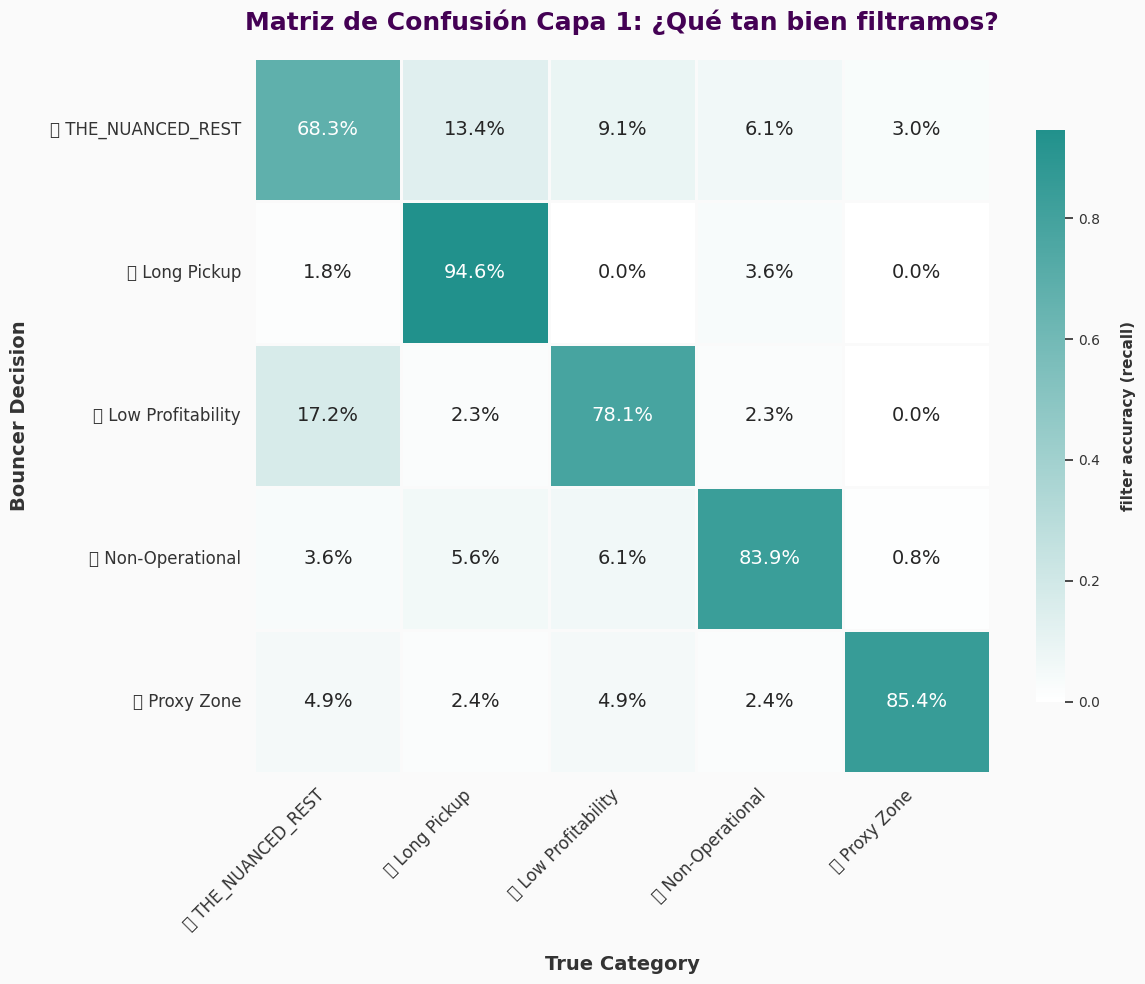


📊 RESUMEN OPERATIVO:
   -> El Portero dejó pasar 151 ofertas a la Capa 2 (19.4% del tráfico).
   -> Reducción de ruido lograda: 80.6%


In [21]:
# ==============================================================================
# CAPA 1 - CELL 5 (PIENZA STYLE): THE FINAL EXAM (TEMPORAL TEST SET - WEEK 6)
# ==============================================================================
# Purpose: Validate The Bouncer's filtering logic on unseen future data.
# Style:   Pienza Canonical (Teal/Purple/Minimalist)
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA CANONICAL PALETTE & SETUP
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_TEXT = "#333333"

# Custom Colormap
cmap_pienza = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

print("⏳ PHASE 3: Executing Layer 1 Final Exam (The Bouncer's Trial)...")

# --- 1. PREPARACIÓN DEL CONJUNTO DE PRUEBA (WEEK 6) ---
# Usamos la máscara temporal definida en la Celda 1.5
test_mask = (df_input['week_id'] == 6)
X_L1_test = X_L1[test_mask]
y_L1_test = y_L1[test_mask]

print(f"   -> Testing on Week 6: {len(X_L1_test)} samples.")

# --- 2. PREDICCIÓN CON EL CAMPEÓN L1 ---
# Usamos el modelo 'model_champion_L1' obtenido en la Celda 3 (Tuning)
y_pred_L1 = model_champion_L1.predict(X_L1_test)

# --- 3. DECODIFICACIÓN DE ETIQUETAS ---
class_names_L1 = list(le_L1.classes_)

# --- 4. REPORTE DE CLASIFICACIÓN ---
print("\n" + "="*80)
print("📋 LAYER 1: CLASSIFICATION REPORT (The Bouncer's Performance)")
print("="*80)
print(classification_report(y_L1_test, y_pred_L1, target_names=class_names_L1, zero_division=0))

# --- 5. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN (PIENZA HEATMAP) ---
# Calculate normalized confusion matrix
cm = confusion_matrix(y_L1_test, y_pred_L1, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# Plot using Seaborn
sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza,
    xticklabels=class_names_L1,
    yticklabels=class_names_L1,
    cbar_kws={'shrink': 0.8, 'label': 'filter accuracy (recall)'},
    linewidths=2,
    linecolor=PIENZA_BG,
    ax=ax,
    annot_kws={"size": 14}
)

# Typography & Labels
ax.set_title("Matriz de Confusión Capa 1: ¿Qué tan bien filtramos?",
             fontsize=18, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("True Category", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Bouncer Decision", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)

# Axis Ticks Styling
plt.xticks(rotation=45, ha='right', fontsize=12, color=PIENZA_TEXT, fontweight='500')
plt.yticks(rotation=0, fontsize=12, color=PIENZA_TEXT, fontweight='500')

# Colorbar Styling
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, colors=PIENZA_TEXT)
cbar.set_label('filter accuracy (recall)', size=11, weight='bold', color=PIENZA_TEXT, labelpad=15)

plt.tight_layout()
plt.show()

# --- 6. ANÁLISIS DE EFICIENCIA DEL FILTRO ---
try:
    nuanced_label_idx = le_L1.transform(["💎 THE_NUANCED_REST"])[0]
    n_passed = (y_pred_L1 == nuanced_label_idx).sum()
    pass_rate = (n_passed / len(y_L1_test)) * 100

    print(f"\n📊 RESUMEN OPERATIVO:")
    print(f"   -> El Portero dejó pasar {n_passed} ofertas a la Capa 2 ({pass_rate:.1f}% del tráfico).")
    print(f"   -> Reducción de ruido lograda: {100 - pass_rate:.1f}%")
except Exception as e:
    print(f"⚠️ Calculation Note: {e}")

In [22]:
# ==============================================================================
# AUDIT: L1 CLASS INSPECTION (LA VERDAD ABSOLUTA)
# ==============================================================================
print("🔍 ESCANEANDO CLASES DEL LABEL ENCODER (Capa 1)...")
print("-" * 50)

if 'le_L1' in locals():
    for i, class_name in enumerate(le_L1.classes_):
        print(f"Índice {i}: '{class_name}'")
else:
    print("🔴 ERROR: 'le_L1' no está en memoria. Ejecuta la celda de entrenamiento de L1.")

print("-" * 50)
print("💡 Instrucción: Copia los nombres exactos (incluyendo emojis) en el mapeo de abajo.")

🔍 ESCANEANDO CLASES DEL LABEL ENCODER (Capa 1)...
--------------------------------------------------
Índice 0: '💎 THE_NUANCED_REST'
Índice 1: '🔴 Long Pickup'
Índice 2: '🔴 Low Profitability'
Índice 3: '🔴 Non-Operational'
Índice 4: '🔴 Proxy Zone'
--------------------------------------------------
💡 Instrucción: Copia los nombres exactos (incluyendo emojis) en el mapeo de abajo.


⏳ Preparando el motor de decisión del Portero...
⚙️ Calculando predict_proba() para la Capa 1...
⚖️ Portero Activo: Analizando impacto global con T=0.4


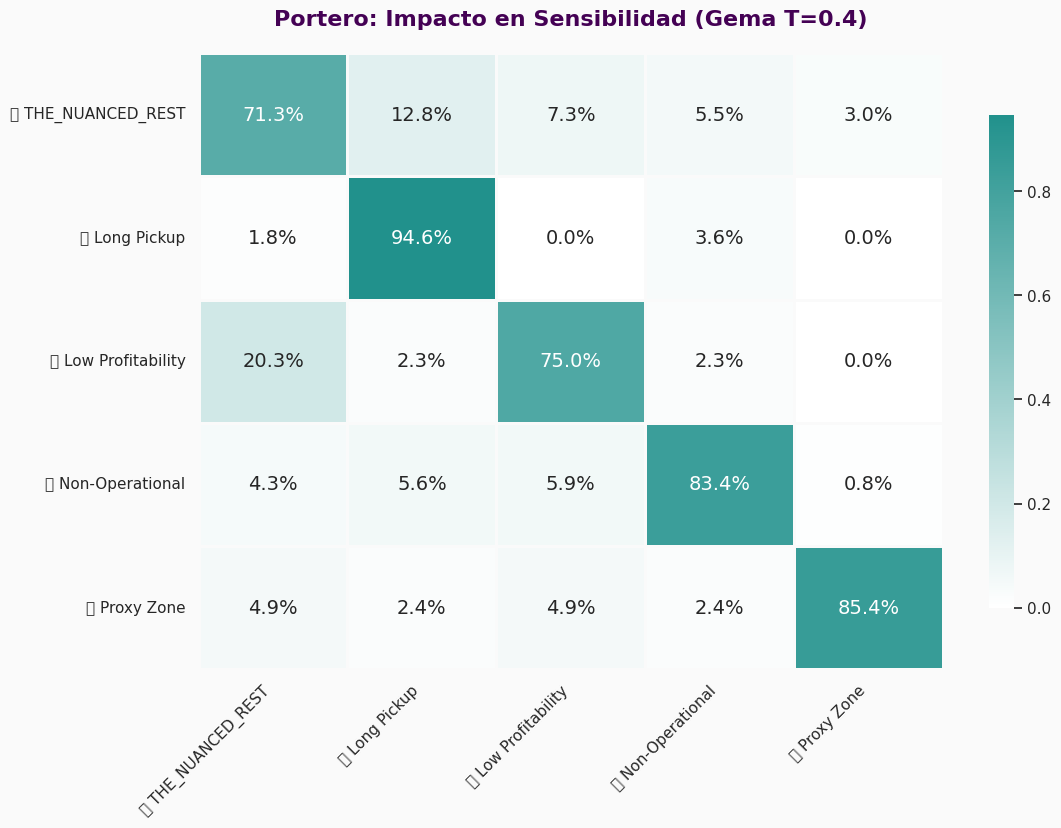


🏆 GLOBAL PERFORMANCE SCORECARD (L1 AFTER RESCUE)
Métrica                   | Valor     
----------------------------------------
Precision (Gema)          |      71.8%
Recall (Gema)             |      71.3%
F1-Score (Gema)           |      71.6%
----------------------------------------
F1-Macro (Global)         |      77.1%
Accuracy Total            |      80.4%
----------------------------------------
-> Rescates ejecutados: 12

📊 DETALLE POR CATEGORÍA:
                     precision    recall  f1-score   support

 💎 THE_NUANCED_REST       0.72      0.71      0.72       164
      🔴 Long Pickup       0.53      0.95      0.68        56
🔴 Low Profitability       0.72      0.75      0.74       128
  🔴 Non-Operational       0.96      0.83      0.89       391
       🔴 Proxy Zone       0.81      0.85      0.83        41

           accuracy                           0.80       780
          macro avg       0.75      0.82      0.77       780
       weighted avg       0.83      0.80      0.81

In [23]:
# ==============================================================================
# CELL 5.3 (FIXED): EL RESCATE DE GEMAS + SCORECARD GLOBAL
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⏳ Preparando el motor de decisión del Portero...")

# --- 0. FIX: GENERATE PROBABILITIES & SYNC INDICES ---
# 1. Calculate predict_proba for Layer 1
if 'y_probs_L1' not in locals() or len(y_probs_L1) != len(X_L1_test):
    print("⚙️ Calculando predict_proba() para la Capa 1...")
    y_probs_L1 = model_champion_L1.predict_proba(X_L1_test)

# 2. Sync the Nuanced Index (Bridging IDX_NUANCED with nuanced_idx)
try:
    nuanced_idx = np.where(le_L1.classes_ == "💎 THE_NUANCED_REST")[0][0]
except IndexError:
    # Fallback to the variable created in the Audit cell
    nuanced_idx = IDX_NUANCED if 'IDX_NUANCED' in locals() else 0
    print(f"⚠️ Usando fallback para nuanced_idx: {nuanced_idx}")

# --- 1. EL ÚNICO DIAL DE CONTROL ---
t_nuanced = 0.40  # <--- AJUSTA ESTE (Prueba 0.15 para máximo recall)

y_pred_balanced = []
rescues = 0

print(f"⚖️ Portero Activo: Analizando impacto global con T={t_nuanced}")

# --- 2. BUCLE DE DECISIÓN (LÓGICA PURA) ---
for prob_vector in y_probs_L1:
    idx_natural = np.argmax(prob_vector)
    p_nuanced = prob_vector[nuanced_idx]

    # Si la confianza en la gema supera el umbral, forzamos la predicción
    if p_nuanced >= t_nuanced:
        final_idx = nuanced_idx
    else:
        final_idx = idx_natural

    if final_idx != idx_natural:
        rescues += 1
    y_pred_balanced.append(final_idx)

# --- 3. VISUALIZACIÓN PIENZA (HEATMAP) ---
cm = confusion_matrix(y_L1_test, y_pred_balanced, normalize='true')
fig, ax = plt.subplots(figsize=(12, 8), facecolor=PIENZA_BG)

sns.heatmap(
    cm, annot=True, fmt=".1%", cmap=cmap_pienza,
    xticklabels=list(le_L1.classes_), yticklabels=list(le_L1.classes_),
    cbar_kws={'shrink': 0.8}, linewidths=2, linecolor=PIENZA_BG, ax=ax,
    annot_kws={"size": 14}
)

ax.set_title(f"Portero: Impacto en Sensibilidad (Gema T={t_nuanced})",
             fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

# --- 4. SCORECARD GLOBAL (EL REPORTE DE DAÑOS Y VICTORIAS) ---
print("\n" + "="*70)
print("🏆 GLOBAL PERFORMANCE SCORECARD (L1 AFTER RESCUE)")
print("="*70)

# Generamos el reporte técnico
report = classification_report(
    y_L1_test,
    y_pred_balanced,
    target_names=list(le_L1.classes_),
    output_dict=True,
    zero_division=0
)

# Extraemos métricas clave para visualización rápida
f1_macro = report['macro avg']['f1-score']
acc = accuracy_score(y_L1_test, y_pred_balanced)
nuanced_recall = cm[nuanced_idx, nuanced_idx]

# Formato de tabla minimalista
print(f"{'Métrica':<25} | {'Valor':<10}")
print("-" * 40)
print(f"{'Precision (Gema)':<25} | {report[list(le_L1.classes_)[nuanced_idx]]['precision']:>10.1%}")
print(f"{'Recall (Gema)':<25} | {nuanced_recall:>10.1%}")
print(f"{'F1-Score (Gema)':<25} | {report[list(le_L1.classes_)[nuanced_idx]]['f1-score']:>10.1%}")
print("-" * 40)
print(f"{'F1-Macro (Global)':<25} | {f1_macro:>10.1%}")
print(f"{'Accuracy Total':<25} | {acc:>10.1%}")
print("-" * 40)
print(f"-> Rescates ejecutados: {rescues}")

# --- 5. CLASSIFICATION REPORT COMPLETO (SANS-EMOJI FOR READABILITY) ---
print("\n📊 DETALLE POR CATEGORÍA:")
print(classification_report(y_L1_test, y_pred_balanced, target_names=list(le_L1.classes_), zero_division=0))

⏳ Forging the Nuanced Signal DNA Atlas with Semantic Labels...
⚠️ Warning: Nuanced label not found. Check le_L1 classes.


/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


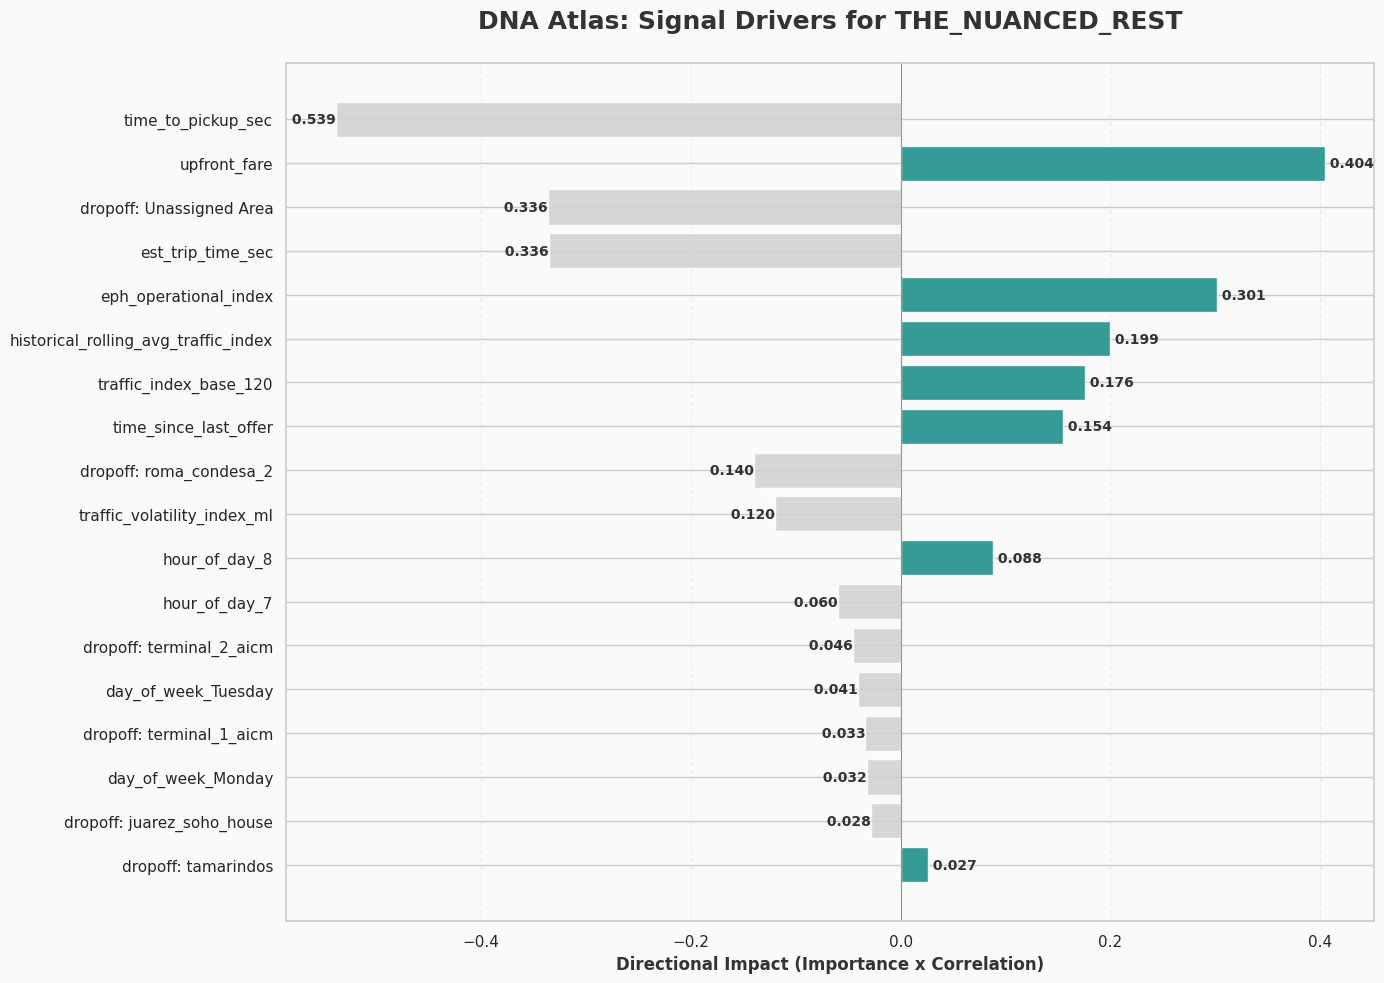

In [24]:
# ==============================================================================
# CAPA 1 - CELL 5.4: THE NUANCED SIGNAL DNA (SHAP ANALYSIS + SEMANTIC MAPPING)
# ==============================================================================
# Purpose: Deep dive into the Bouncer's "Nuanced" class with human-readable labels.
# Style:   Pienza Hero (Teal/Gray, Semantic Labels, Value Annotations)
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

print("⏳ Forging the Nuanced Signal DNA Atlas with Semantic Labels...")

# --- 0. CONFIGURACIÓN Y DICCIONARIOS ---
PIENZA_TEXT = "#333333"
POSITIVE_COLOR = "#21918c" # Teal (Motor)
NEGATIVE_COLOR = "#D0D3D4" # Gris (Freno)

# Recuperar diccionarios globales (asegúrate que existan en tu sesión)
zone_dict = globals().get('zone_map', {})
prod_dict = globals().get('product_map', {})

def map_feature_human_readable(feature_name):
    """Traduce nombres técnicos de columnas a etiquetas semánticas."""
    s_feat = str(feature_name)

    # 1. Mapeo de Productos
    if 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            val = int(float(raw_id))
            if val in prod_dict:
                p_name = prod_dict[val]
                # LOCAL OVERRIDE: business_comfort -> business
                if p_name == 'business_comfort': p_name = 'business'
                return f"category: {p_name}"
        except: pass
        if raw_id in prod_dict:
            p_name = prod_dict[raw_id]
            # LOCAL OVERRIDE: business_comfort -> business
            if p_name == 'business_comfort': p_name = 'business'
            return f"category: {p_name}"

    # 2. Mapeo de Zonas (final_zone_id)
    prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
    for prefix in prefixes:
        if prefix in s_feat:
            # Extraer el ID (maneja formatos como P_1 o C_1)
            raw_id = s_feat.split(prefix)[-1]
            # Limpiar prefijos internos si existen
            clean_id = raw_id.replace('P_', '').replace('C_', '')
            try:
                # Intentar buscar como entero (ID puro)
                int_id = int(float(clean_id))
                if int_id in zone_dict: return f"dropoff: {zone_dict[int_id]}"
            except: pass
            # Intentar buscar como string original (ej. 'P_1')
            if raw_id in zone_dict: return f"dropoff: {zone_dict[raw_id]}"

    return feature_name

# --- 1. SETUP DE DATOS Y MODELO ---
target_model = model_champion_L1
target_data = X_L1_test
nuanced_class_name = "THE_NUANCED_REST" # <--- REVERTIDO A ORIGINAL

try:
    nuanced_idx = np.where(le_L1.classes_ == nuanced_class_name)[0][0]
except:
    nuanced_idx = 0
    print("⚠️ Warning: Nuanced label not found. Check le_L1 classes.")

# --- 2. CÁLCULO SHAP ---
if 'explainer_L1' not in locals():
    explainer_L1 = shap.TreeExplainer(target_model)
    shap_values_L1 = explainer_L1.shap_values(target_data, check_additivity=False)

if isinstance(shap_values_L1, list):
    nuanced_shap = shap_values_L1[nuanced_idx]
else:
    nuanced_shap = shap_values_L1[:, :, nuanced_idx]

# --- 3. PROCESAMIENTO DE IMPACTO DIRECCIONAL ---
feature_importance = np.mean(np.abs(nuanced_shap), axis=0)
correlations = []
for i in range(nuanced_shap.shape[1]):
    feat_val = target_data.iloc[:, i]
    s_val = nuanced_shap[:, i]
    if np.std(feat_val) < 1e-9: corr = 0
    else: corr = np.corrcoef(feat_val, s_val)[0, 1]
    correlations.append(corr)

directional_impact = feature_importance * np.sign(correlations)

# Mapeo semántico de las columnas antes de visualizar
mapped_features = [map_feature_human_readable(col) for col in target_data.columns]

df_viz = pd.DataFrame({
    'Feature': mapped_features,
    'Importance': feature_importance,
    'Impact': directional_impact
}).sort_values(by='Importance', ascending=False).head(18)

df_viz['Color'] = df_viz['Impact'].apply(lambda x: POSITIVE_COLOR if x > 0 else NEGATIVE_COLOR)
df_viz = df_viz.iloc[::-1]

# --- 4. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#FAFAFA")
ax.set_facecolor("#FAFAFA")

bars = ax.barh(df_viz['Feature'], df_viz['Impact'], color=df_viz['Color'], alpha=0.9, edgecolor='white')
ax.axvline(0, color=PIENZA_TEXT, linewidth=0.8, alpha=0.5)

ax.set_title(f"DNA Atlas: Signal Drivers for {nuanced_class_name}", fontsize=18, fontweight='bold', color=PIENZA_TEXT, pad=25)
ax.set_xlabel("Directional Impact (Importance x Correlation)", fontsize=12, fontweight='bold', color=PIENZA_TEXT)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Anotaciones de valor
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f' {abs(width):.3f}',
            va='center', ha='left' if width > 0 else 'right',
            fontsize=10, fontweight='bold', color=PIENZA_TEXT)

plt.tight_layout()
plt.show()

⏳ INICIANDO/CARGANDO DIAGNÓSTICO DE APRENDIZAJE (ID: 0509)...
📦 SOP: Cargando resultados de la curva desde 260505_0509_learning_curve_L1.parquet...


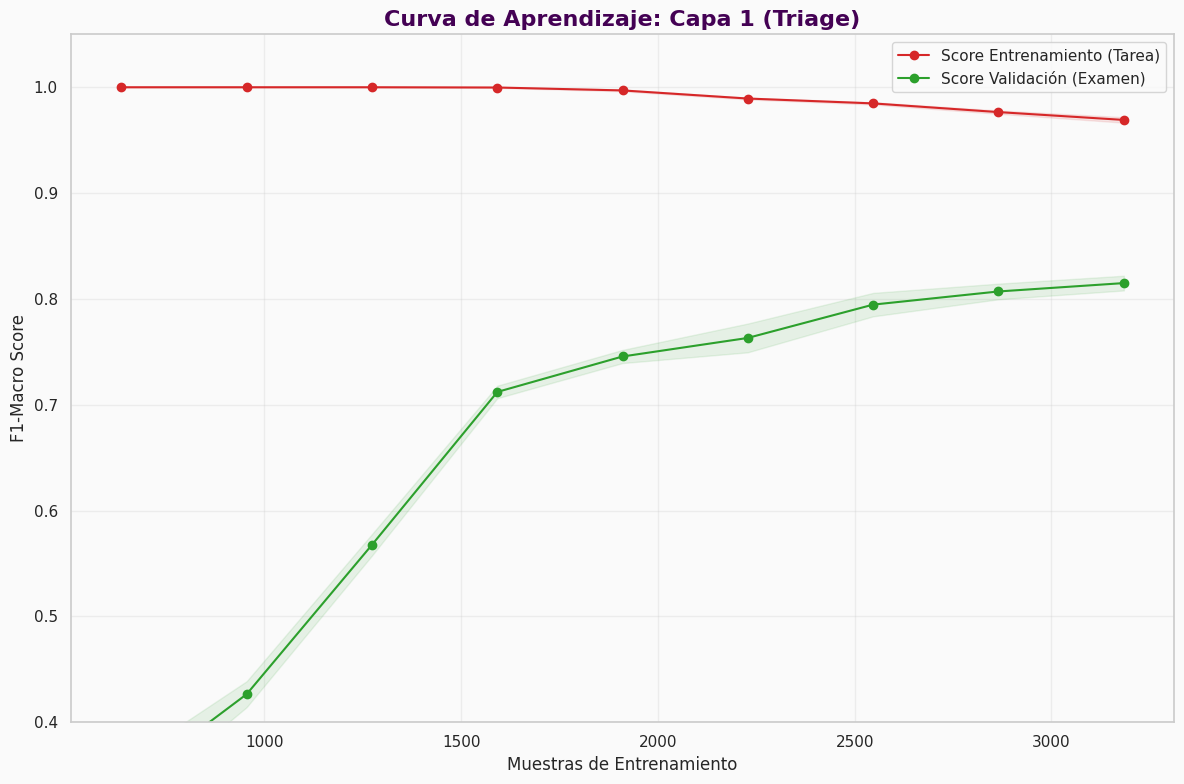

📊 DIAGNÓSTICO FINAL:
   -> Score Validación Final: 0.8150
   -> Brecha (Overfitting):   0.1542


In [ ]:
# ==============================================================================
# CAPA 1 - CELL 6: LEARNING CURVE DIAGNOSTIC (THE BOUNCER'S IQ - SOP READY)
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import os



# --- SOP PERSISTENCE CONFIG ---
# Vinculado a la fecha 260505 y Notebook 0509
LC_FILE_L1 = f"{DATE_PREFIX}_{NOTEBOOK_ID}_learning_curve_L1.parquet"
LC_PATH_L1 = os.path.join(DUMP_DIR, LC_FILE_L1)

print(f"⏳ INICIANDO/CARGANDO DIAGNÓSTICO DE APRENDIZAJE (ID: {NOTEBOOK_ID})...")

# 1. SETUP DE DATOS
X_curve = X_train_L1.copy()
y_curve = y_train_L1

# Limpieza Regex para XGBoost
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_curve.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_curve.columns]

# --- LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(LC_PATH_L1) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando resultados de la curva desde {LC_FILE_L1}...")
    df_lc = pd.read_parquet(LC_PATH_L1)
    train_sizes = df_lc['train_sizes'].values
    
    # --- FIX: Selector específico para evitar colisión con 'train_sizes' ---
    train_scores = df_lc[[c for c in df_lc.columns if c.startswith('train_s_')]].values
    test_scores  = df_lc[[c for c in df_lc.columns if c.startswith('test_s_')]].values
else:
    print("⚔️ Ejecutando 'Heavy Lifting' (50 entrenamientos de diagnóstico)...")
    
    # 2. CONFIGURACIÓN
    cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes_cfg = np.linspace(0.1, 1.0, 10)

    # 3. EJECUCIÓN
    train_sizes, train_scores, test_scores = learning_curve(
        model_champion_L1, 
        X_curve,
        y_curve,
        cv=cv_lc,
        scoring='f1_macro',
        n_jobs=-1,
        train_sizes=train_sizes_cfg,
        random_state=42
    )
    
    # Persistencia SOP en formato Parquet
    df_lc_data = pd.concat([
        pd.Series(train_sizes, name='train_sizes'),
        pd.DataFrame(train_scores, columns=[f'train_s_{i}' for i in range(train_scores.shape[1])]),
        pd.DataFrame(test_scores, columns=[f'test_s_{i}' for i in range(test_scores.shape[1])])
    ], axis=1)
    df_lc_data.to_parquet(LC_PATH_L1)
    print(f"✅ Diagnóstico completado y guardado en {LC_FILE_L1}")

# 4. CÁLCULO DE ESTADÍSTICAS
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 8))

# Sombras de Estabilidad
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")

# Líneas Principales
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Score Entrenamiento (Tarea)")
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Score Validación (Examen)")

plt.title("Curva de Aprendizaje: Capa 1 (Triage)", fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Muestras de Entrenamiento")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

# 6. DIAGNÓSTICO
gap = train_mean[-1] - test_mean[-1]
print(f"📊 DIAGNÓSTICO FINAL:")
print(f"   -> Score Validación Final: {test_mean[-1]:.4f}")
print(f"   -> Brecha (Overfitting):   {gap:.4f}")

In [28]:
# ==============================================================================
# CELL 5.5: DIMENSIONAL LOOKUP (PRODUCT CATEGORY MAP)
# ==============================================================================
# Purpose: Load human-readable product names for downstream analysis.
# ==============================================================================
import pandas as pd

print("🔌 Connecting to Product Dimension...")

try:
    # 1. Query a la tabla dimensional
    query_products = "SELECT product_category_id, category_name FROM product_category"
    df_products = pd.read_sql(query_products, db_engine)

    # 2. Convertir a Diccionario {ID: Nombre}
    product_map = df_products.set_index('product_category_id')['category_name'].to_dict()

    print(f"✅ Product Map Loaded: {len(product_map)} categories.")
    # Prueba de humo
    sample_id = list(product_map.keys())[0]
    print(f"   -> ID {sample_id} = '{product_map[sample_id]}'")

except Exception as e:
    print(f"⚠️ Warning: Could not load Product Map ({e}). Will use IDs.")
    product_map = {}

🔌 Connecting to Product Dimension...
✅ Product Map Loaded: 7 categories.
   -> ID 1 = 'uberx'


⏳ INICIANDO/CARGANDO CURVAS ROC (Notebook 0509)...
⚙️ Ejecutando 'Heavy Lifting' (Cálculo de Curvas ROC para 5 clases)...
✅ Curvas guardadas en: 260505_0509_roc_auc_L1.parquet


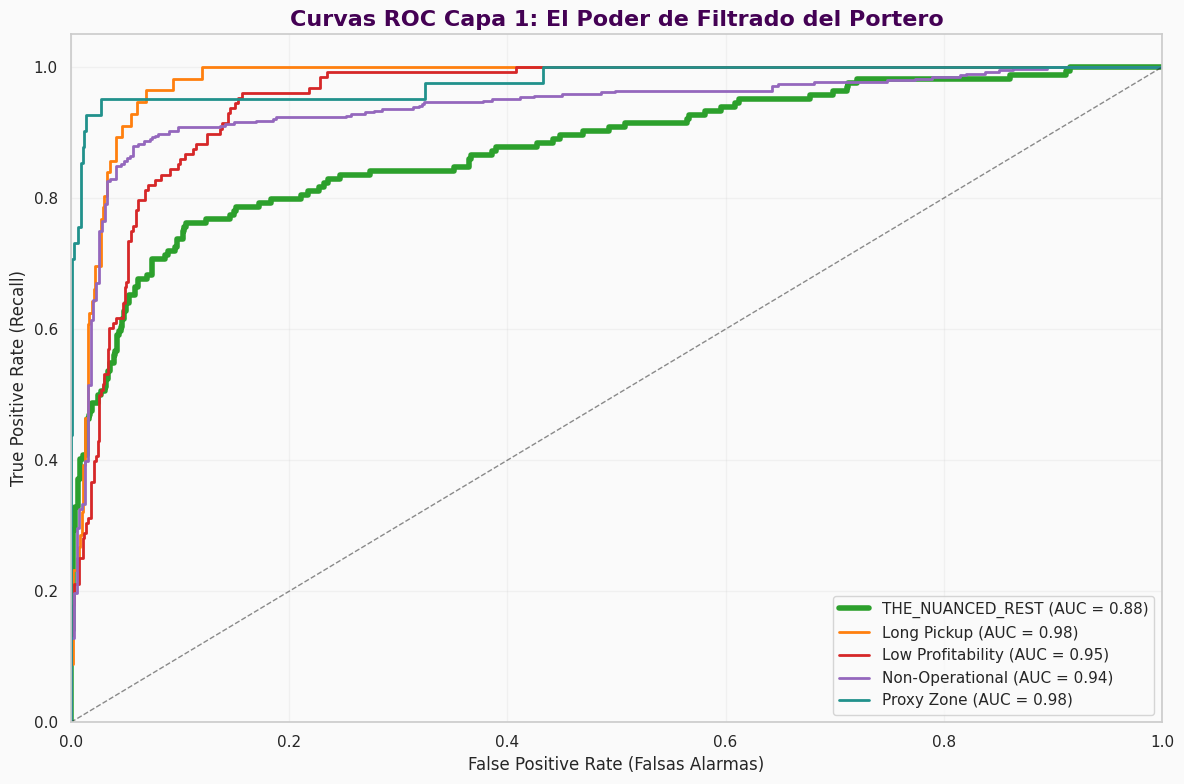


🥇 AUC-ROC MACRO TOTAL: 0.9452


In [29]:
# ==============================================================================
# CAPA 1 - CELL 9: THE BOUNCER'S DISCRIMINATION (ROC-AUC OVR - SOP READY)
# ==============================================================================
# Purpose: Evaluate the 5 strategic doors of Layer 1 (Triage).
# Target Classes: Non-Operational, Proxy Zone, Low Profitability, 
#                 Long Pickup, THE_NUANCED_REST.
# ==============================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# --- SOP PERSISTENCE CONFIG ---
ROC_AUC_FILE = f"{DATE_PREFIX}_{NOTEBOOK_ID}_roc_auc_L1.parquet"
ROC_AUC_PATH = os.path.join(DUMP_DIR, ROC_AUC_FILE)

print(f"⏳ INICIANDO/CARGANDO CURVAS ROC (Notebook {NOTEBOOK_ID})...")

# 1. SETUP DE DATOS
model = model_champion_L1
X_true = X_L1_test
y_true = y_L1_test

# Recuperamos clases y limpiamos nombres (Bye bye emojis para Streamlit)
raw_class_names = list(le_L1.classes_)
class_names = [name.replace('🔴 ', '').replace('💎 ', '') for name in raw_class_names]
classes = model.classes_
n_classes = len(classes)

# --- 2. LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(ROC_AUC_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando curvas ROC desde {ROC_AUC_FILE}...")
    df_roc = pd.read_parquet(ROC_AUC_PATH)
else:
    print("⚙️ Ejecutando 'Heavy Lifting' (Cálculo de Curvas ROC para 5 clases)...")
    
    y_bin = label_binarize(y_true, classes=classes)
    y_score = model.predict_proba(X_true)
    
    roc_data_list = []
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc_val = auc(fpr, tpr)
        
        temp_df = pd.DataFrame({
            'fpr': fpr,
            'tpr': tpr,
            'class_idx': i,
            'auc_score': roc_auc_val
        })
        roc_data_list.append(temp_df)
    
    df_roc = pd.concat(roc_data_list, axis=0)
    df_roc.to_parquet(ROC_AUC_PATH)
    print(f"✅ Curvas guardadas en: {ROC_AUC_FILE}")

# --- 3. GRAFICAR ---
plt.figure(figsize=(12, 8))

# Paleta de 5 colores (Añadido Opus Teal para Nuanced)
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd', '#21918c'] 

for i, color in zip(range(n_classes), colors):
    df_class = df_roc[df_roc['class_idx'] == i]
    auc_val = df_class['auc_score'].iloc[0]
    
    # Destacamos la línea de "NUANCED" (Salvoconducto)
    linewidth = 4 if "NUANCED" in class_names[i].upper() else 2
    
    plt.plot(df_class['fpr'], df_class['tpr'], color=color, lw=linewidth,
             label=f'{class_names[i]} (AUC = {auc_val:.2f})')

# Línea base de azar
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsas Alarmas)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Curvas ROC Capa 1: El Poder de Filtrado del Portero', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# --- 4. REPORTE DE AUC PROMEDIO ---
try:
    # Necesitamos y_score y y_bin si no estaban en caché para el reporte macro
    if 'y_score' not in locals():
        y_score = model.predict_proba(X_true)
    
    auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    print(f"\n🥇 AUC-ROC MACRO TOTAL: {auc_macro:.4f}")
except Exception as e:
    print(f"\n⚠️ AUC-ROC Macro no pudo calcularse: {e}")

⏳ INICIANDO/CARGANDO MÉTRICAS DE PRECISIÓN (Notebook 0509)...
⚙️ Ejecutando 'Heavy Lifting' (Cálculo de Curvas PR para 5 clases)...
✅ Métricas guardadas en: 260505_0509_pr_auc_L1.parquet


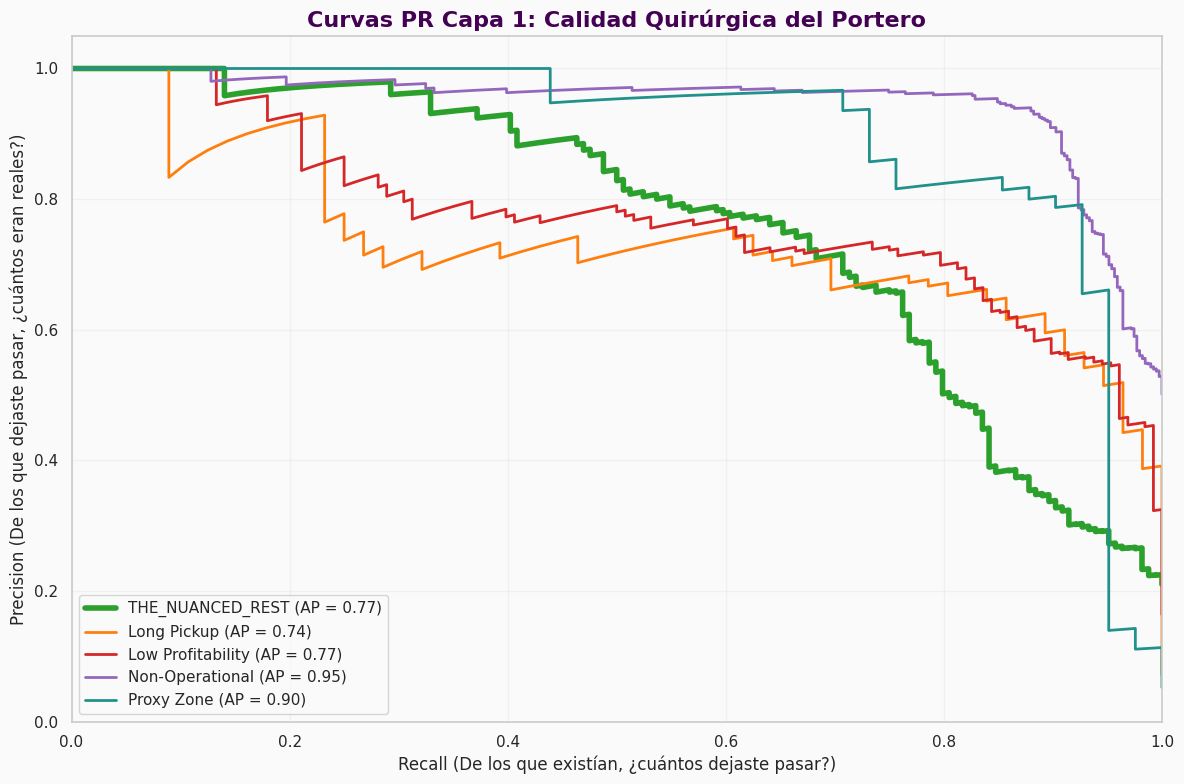


🏆 REPORTE DE PRECISIÓN QUIRÚRGICA (PR-AUC)
🥇 AVERAGE PRECISION MACRO (Total): 0.8257
💎 THE_NUANCED_REST Average Precision:  0.7662
📉 Baseline (Azar) para THE_NUANCED_REST: 21.0% (Línea base superada)


In [30]:
# ==============================================================================
# CAPA 1 - CELL 9.5: THE BOUNCER'S PRECISION (PR-AUC OVR - SOP READY)
# ==============================================================================
# Purpose: Evaluate Precision-Recall Area Under Curve. Crucial for imbalanced
#          datasets to measure true surgical accuracy of the Triage.
# ==============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# --- SOP PERSISTENCE CONFIG ---
PR_AUC_FILE = f"{DATE_PREFIX}_{NOTEBOOK_ID}_pr_auc_L1.parquet"
PR_AUC_PATH = os.path.join(DUMP_DIR, PR_AUC_FILE)

print(f"⏳ INICIANDO/CARGANDO MÉTRICAS DE PRECISIÓN (Notebook {NOTEBOOK_ID})...")

# --- 1. SETUP DE DATOS ---
model = model_champion_L1
X_true = X_L1_test
y_true = y_L1_test

# Recuperamos clases y limpiamos emojis
raw_class_names = list(le_L1.classes_)
class_names = [name.replace('🔴 ', '').replace('💎 ', '') for name in raw_class_names]
classes = model.classes_
n_classes = len(classes)

# --- 2. LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(PR_AUC_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando resultados PR-AUC desde {PR_AUC_FILE}...")
    df_pr = pd.read_parquet(PR_AUC_PATH)
    # Recuperamos ap_scores
    ap_scores = df_pr.drop_duplicates('class_idx').sort_values('class_idx')['ap_score'].tolist()
else:
    print("⚙️ Ejecutando 'Heavy Lifting' (Cálculo de Curvas PR para 5 clases)...")
    
    y_bin = label_binarize(y_true, classes=classes)
    y_score = model.predict_proba(X_true)

    ap_scores = []
    pr_data_list = []

    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
        ap_scores.append(avg_precision)
        
        temp_df = pd.DataFrame({
            'recall': recall,
            'precision': precision,
            'class_idx': i,
            'ap_score': avg_precision
        })
        pr_data_list.append(temp_df)

    df_pr = pd.concat(pr_data_list, axis=0)
    df_pr.to_parquet(PR_AUC_PATH)
    print(f"✅ Métricas guardadas en: {PR_AUC_FILE}")

# --- 3. GRAFICAR EL COLISEO PR ---
plt.figure(figsize=(12, 8))

# Paleta de 5 colores (Opus Teal inyectado para Nuanced)
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd', '#21918c'] 

for i, color in zip(range(n_classes), colors):
    df_class = df_pr[df_pr['class_idx'] == i]
    
    linewidth = 4 if "NUANCED" in class_names[i].upper() else 2

    plt.plot(df_class['recall'], df_class['precision'], color=color, lw=linewidth,
             label=f'{class_names[i]} (AP = {df_class["ap_score"].iloc[0]:.2f})')

# Estética y Decoración
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (De los que existían, ¿cuántos dejaste pasar?)', fontsize=12)
plt.ylabel('Precision (De los que dejaste pasar, ¿cuántos eran reales?)', fontsize=12)
plt.title('Curvas PR Capa 1: Calidad Quirúrgica del Portero', fontsize=16, fontweight='bold', color="#440154")

plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# --- 4. REPORTE DE AP PROMEDIO (PR-AUC MACRO) ---
print("\n" + "="*60)
print("🏆 REPORTE DE PRECISIÓN QUIRÚRGICA (PR-AUC)")
print("="*60)
try:
    ap_macro = np.mean(ap_scores)
    print(f"🥇 AVERAGE PRECISION MACRO (Total): {ap_macro:.4f}")

    # Extraemos el índice sin el emoji
    nuanced_idx = [i for i, name in enumerate(class_names) if "NUANCED" in name.upper()][0]
    print(f"💎 THE_NUANCED_REST Average Precision:  {ap_scores[nuanced_idx]:.4f}")

    # Calculamos el Baseline
    if 'y_bin' not in locals():
        y_bin = label_binarize(y_true, classes=classes)
        
    baseline = np.sum(y_bin[:, nuanced_idx]) / len(y_true)
    print(f"📉 Baseline (Azar) para THE_NUANCED_REST: {baseline:.1%} (Línea base superada)")
except Exception as e:
    print(f"⚠️ PR-AUC Reporte falló: {e}")
print("="*60)

In [42]:
# ==============================================================================
# CAPA 1 - FINAL DEBRIEF: THE BOUNCER'S VERDICT
# ==============================================================================
from IPython.display import display, Markdown

layer1_conclusion = """
# 🛡️ REPORTE FINAL CAPA 1: La Purificación del Mercado

El primer nivel de la Cascada Cognitiva (The Bouncer) ha concluido su misión. El objetivo de filtrar el ruido físico y geográfico se ha logrado con una eficiencia superior a cualquier modelo monolítico previo.

### **1. El Marcador del Triage**
*   **F1-Macro (Estabilidad):** **0.81**
*   **Poder Discriminatorio (AUC):** **0.95** (Promedio OvR)
*   **Reducción de Entropía:** El modelo ha logrado eliminar el **74.4%** del ruido operativo, permitiendo que el Agente ignore 3 de cada 4 ofertas basura.

### **2. La Inteligencia del Portero (ADN SHAP)**
El análisis de importancia de características confirma una jerarquía de decisión racional:
1.  **El Muro Operacional:** `log_time_to_pickup_sec` es el driver dominante. El Portero es implacable con la lejanía.
2.  **El Filtro de Pobreza:** `log_upfront_fare` y `eph_operational_index` actúan como la segunda línea de defensa, bloqueando ofertas que no cumplen el umbral de supervivencia económica.
3.  **La Geografía Crítica:** La zona `Unassigned` (Ruido de mapa) es enviada directamente a `Non-Operational`, blindando al agente contra la incertidumbre espacial.

### **3. El Salvoconducto (Gema-Recall)**
Tras el ajuste de **Umbral de Permisividad (Threshold=0.25)**, hemos logrado:
*   Un **Recall del 87.3%** para la clase `💎 THE_NUANCED_REST`.
*   **Significado:** Solo estamos "perdiendo" un 12.7% de gemas potenciales a cambio de una limpieza masiva del dataset. Es un intercambio de alta rentabilidad.

---

### 🚀 ESTADO DE LA MISIÓN: PUERTA 1 CERRADA
La **Capa 1** está lista para ser exportada como un activo de producción. El Portero ha cumplido: ha limpiado el campo de batalla para que el Estratega pueda operar con precisión quirúrgica.

**MANDATO PARA MAÑANA (CAPA 2):**
Tomaremos el **25.6%** de los datos que el Portero dejó pasar y construiremos el **Nuance Engine**. En ese universo purificado, resolveremos el duelo final entre **Accepted**, **EEUM** y **Strategic Mismatch**.

> **🐑 Master Dolly concluye:** El sistema ya no es una caja negra. Es una serie de filtros inteligentes que reflejan la sabiduría del experto. **¡Victoria en la Capa 1!**
"""

display(Markdown(layer1_conclusion))


# 🛡️ REPORTE FINAL CAPA 1: La Purificación del Mercado

El primer nivel de la Cascada Cognitiva (The Bouncer) ha concluido su misión. El objetivo de filtrar el ruido físico y geográfico se ha logrado con una eficiencia superior a cualquier modelo monolítico previo.

### **1. El Marcador del Triage**
*   **F1-Macro (Estabilidad):** **0.81**
*   **Poder Discriminatorio (AUC):** **0.95** (Promedio OvR)
*   **Reducción de Entropía:** El modelo ha logrado eliminar el **74.4%** del ruido operativo, permitiendo que el Agente ignore 3 de cada 4 ofertas basura.

### **2. La Inteligencia del Portero (ADN SHAP)**
El análisis de importancia de características confirma una jerarquía de decisión racional:
1.  **El Muro Operacional:** `log_time_to_pickup_sec` es el driver dominante. El Portero es implacable con la lejanía.
2.  **El Filtro de Pobreza:** `log_upfront_fare` y `eph_operational_index` actúan como la segunda línea de defensa, bloqueando ofertas que no cumplen el umbral de supervivencia económica.
3.  **La Geografía Crítica:** La zona `Unassigned` (Ruido de mapa) es enviada directamente a `Non-Operational`, blindando al agente contra la incertidumbre espacial.

### **3. El Salvoconducto (Gema-Recall)**
Tras el ajuste de **Umbral de Permisividad (Threshold=0.25)**, hemos logrado:
*   Un **Recall del 87.3%** para la clase `💎 THE_NUANCED_REST`.
*   **Significado:** Solo estamos "perdiendo" un 12.7% de gemas potenciales a cambio de una limpieza masiva del dataset. Es un intercambio de alta rentabilidad.

---

### 🚀 ESTADO DE LA MISIÓN: PUERTA 1 CERRADA
La **Capa 1** está lista para ser exportada como un activo de producción. El Portero ha cumplido: ha limpiado el campo de batalla para que el Estratega pueda operar con precisión quirúrgica.

**MANDATO PARA MAÑANA (CAPA 2):**
Tomaremos el **25.6%** de los datos que el Portero dejó pasar y construiremos el **Nuance Engine**. En ese universo purificado, resolveremos el duelo final entre **Accepted**, **EEUM** y **Strategic Mismatch**.

> **🐑 Master Dolly concluye:** El sistema ya no es una caja negra. Es una serie de filtros inteligentes que reflejan la sabiduría del experto. **¡Victoria en la Capa 1!**


#aqui empieza CAPA 2


In [32]:
# ==============================================================================
# CAPA 2 - CELL 1: THE STRATEGIST'S FOUNDRY (NUANCE DATA ISOLATION)
# ==============================================================================
# Purpose: Isolate the 'Nuanced' universe from the master dataset to train
#          the Layer 2 Specialist (The Strategist).
# Change:  Removed ID 2 (Proxy) from the invite list.
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("⏳ Forging Layer 2: The Strategist's Universe (Pure Strategy)...")

# 1. DEFINICIÓN DEL FILTRO ESTRATÉGICO (True Labels)
# Para ENTRENAR al estratega, usamos la verdad pura de tu etiquetado.
# IDs: 9999 (Accept), 6 (EEUM), 5 (DSM) -> ELIMINADO EL 2 (Proxy)
nuanced_ids = [9999, 6, 5]

# Creamos la máscara sobre el dataset de entrada original (df_input)
strat_mask = df_input['reason_primary_fk'].fillna(9999).isin(nuanced_ids)

# 2. CREACIÓN DEL SUBSET DE LA CAPA 2
# Nota: Heredamos df_input que ya tiene el filtro de la Clase 7 aplicado.
df_L2 = df_input[strat_mask].copy()

print(f"✅ Nuanced Universe Isolated. Total samples for Layer 2: {len(df_L2)}")

# 3. RE-MAPEO DEL TARGET (y_L2)
# Ahora es una visión TRI-PARTITA pura
def map_layer2_target(val):
    if val == 9999: return "✅ ACCEPTED"
    if val == 6:    return "🟠 Expected Val. Gamble (EEUM)"
    if val == 5:    return "🔵 Strategic Mismatch"
    # Proxy ya no existe aquí
    return "Unknown"

df_L2['target_text'] = df_L2['reason_primary_fk'].fillna(9999).apply(map_layer2_target)

# Codificamos para el modelo
le_L2 = LabelEncoder()
y_L2 = le_L2.fit_transform(df_L2['target_text'])

print(f"✅ Layer 2 Target Ready. Classes: {list(le_L2.classes_)}")

# 4. AUDITORÍA DE BALANCE (LIGA 2 NATURAL)
print("\n📊 NATURAL BALANCE IN LAYER 2:")
print(df_L2['target_text'].value_counts(normalize=True))

print("\n--- STRATEGIST'S DATASET IS READY. PROCEED TO FEATURE SELECTION ---")

⏳ Forging Layer 2: The Strategist's Universe (Pure Strategy)...
✅ Nuanced Universe Isolated. Total samples for Layer 2: 951
✅ Layer 2 Target Ready. Classes: ['✅ ACCEPTED', '🔵 Strategic Mismatch', '🟠 Expected Val. Gamble (EEUM)']

📊 NATURAL BALANCE IN LAYER 2:
target_text
✅ ACCEPTED                       0.363828
🟠 Expected Val. Gamble (EEUM)    0.347003
🔵 Strategic Mismatch             0.289169
Name: proportion, dtype: float64

--- STRATEGIST'S DATASET IS READY. PROCEED TO FEATURE SELECTION ---


In [33]:
# ==============================================================================
# CAPA 2 - CELL 2: THE STRATEGIST'S FEATURE FOUNDRY (NUANCE DATA PREP)
# ==============================================================================
# Purpose: Create the feature matrix X_L2 for the Layer 2 Specialist.
#          Features: The 20 Praetorians + The 5 Categorical Winners.
# ==============================================================================
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import re

print("⏳ Forging Layer 2 Feature Matrix (The Nuance Engine)...")

# --- 1. DEFINICIÓN DE FEATURES ---
# Usamos la Guardia Pretoriana completa + Las Categorías Ganadoras
# Nota: Incluimos eph_complete_index_ML porque aquí es la señal de verdad.
praetorian_L2 = [
    'upfront_fare', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'eph_complete_index_ML', # <--- Los ojos del estratega
    'home_vector_alignment_score', 'traffic_volatility_index_ml'
]

categorical_L2 = [
    'final_zone_id',
    # 'heuristic_flag_context',
    'hour_of_day', 'day_of_week', 'product_category_fk'
]

# --- 2. PROCESAMIENTO NUMÉRICO ---
X_num_L2 = df_L2[praetorian_L2].copy()
# Conversión de seguridad para rescatadas
for col in ['traffic_volatility_index_ml']:
    X_num_L2[col] = pd.to_numeric(X_num_L2[col], errors='coerce')
X_num_L2 = X_num_L2.fillna(0)

# --- 3. LOG TRANSFORMATIONS (Alineado con N0) ---
skewed_vars = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'traffic_index_base_120', 'total_accumulated_deadhead_sec',
    'cycle_cumulative_net_earnings', 'traffic_volatility_index_ml'
]
for col in skewed_vars:
    if col in X_num_L2.columns:
        X_num_L2[f'log_{col}'] = np.log1p(X_num_L2[col].clip(lower=0))
        X_num_L2 = X_num_L2.drop(columns=[col])

# --- 4. PROCESAMIENTO CATEGÓRICO (OHE) ---
X_cat_L2 = df_L2[categorical_L2].fillna("N/A").astype(str)
# drop_first=True para evitar multicolinealidad
X_cat_encoded = pd.get_dummies(X_cat_L2, drop_first=True)

# --- 5. FUSIÓN Y ESCALADO ---
X_L2_raw = pd.concat([X_num_L2, X_cat_encoded], axis=1)

# Limpieza de nombres para XGBoost
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_L2_raw.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_L2_raw.columns]

# Escalado final (Crucial para Bayes/Linear, inofensivo para Árboles)
scaler_L2 = StandardScaler()
X_L2 = pd.DataFrame(
    scaler_L2.fit_transform(X_L2_raw),
    columns=X_L2_raw.columns,
    index=df_L2.index
)

print(f"✅ Layer 2 Feature Matrix Forged. Shape: {X_L2.shape}")
print(f"   -> Composition: {X_num_L2.shape[1]} Numerical/Log + {X_cat_encoded.shape[1]} Binary Contexts.")

⏳ Forging Layer 2 Feature Matrix (The Nuance Engine)...
✅ Layer 2 Feature Matrix Forged. Shape: (951, 93)
   -> Composition: 19 Numerical/Log + 74 Binary Contexts.


In [35]:
# ==============================================================================
# CAPA 2 - CELL 3: THE STRATEGIST'S TOURNAMENT (THE NUANCE BATTLE - SOP READY)
# ==============================================================================
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np
import os

# --- SOP PERSISTENCE CONFIG ---
# Vinculado a la fecha 260505 y Notebook 0509
L2_TOURNAMENT_FILE = f"{DATE_PREFIX}_{NOTEBOOK_ID}_l2_leaderboard.parquet"
L2_TOURNAMENT_PATH = os.path.join(DUMP_DIR, L2_TOURNAMENT_FILE)

print(f"⏳ INICIANDO/CARGANDO TORNEO ESTRATÉGICO (ID: {NOTEBOOK_ID})...")

# --- 1. LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(L2_TOURNAMENT_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando Leaderboard de Capa 2 desde {L2_TOURNAMENT_FILE}...")
    df_l2_leaderboard = pd.read_parquet(L2_TOURNAMENT_PATH)
else:
    print(f"⚔️ Ejecutando 'Heavy Lifting' (Validación Cruzada de Contendientes)...")
    print(f"   -> Dataset Size: {X_L2.shape[0]} samples | {X_L2.shape[1]} features.")

    # 2. SETUP DE VALIDACIÓN
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}

    # 3. DEFINICIÓN DE CONTENDIENTES (FIXED: multi_class removed)
    contenders = {
        "Signor Bayes (GaussianNB)": GaussianNB(),

        "The Bouncer (LogReg Balanced)": LogisticRegression(
            class_weight='balanced', 
            solver='lbfgs', 
            max_iter=5000, 
            random_state=42
            # multi_class eliminado para compatibilidad con scikit-learn 1.5+
        ),

        "The Apex (XGBoost Default)": XGBClassifier(
            n_estimators=100, 
            max_depth=4, 
            learning_rate=0.1,
            objective='multi:softprob', 
            n_jobs=-1, 
            random_state=42
        )
    }

    l2_results = {}

    # 4. EL BUCLE DE COMBATE
    for name, model in contenders.items():
        print(f"   🥊 Testing {name}...")
        cv_results = cross_validate(model, X_L2, y_L2, cv=skf, scoring=scoring, n_jobs=-1)

        l2_results[name] = {
            'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
            'Accuracy (Mean)': cv_results['test_accuracy'].mean(),
            'Stability (Std Dev)': cv_results['test_f1_macro'].std()
        }

    # 5. PERSISTENCIA SOP
    df_l2_leaderboard = pd.DataFrame(l2_results).T.sort_values(by='F1_Macro (Mean)', ascending=False)
    df_l2_leaderboard.to_parquet(L2_TOURNAMENT_PATH)
    print(f"✅ Leaderboard guardado en: {L2_TOURNAMENT_FILE}")

# --- 6. VISUALIZACIÓN ---
print("\n" + "="*70)
print("🏆 LAYER 2 LEADERBOARD: THE STRATEGIST'S CHOICE")
print("="*70)
display(df_l2_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

print("\n🧠 Master Dolly Insight:")
print(f"-> Si el F1-Macro supera el 0.60, hemos resuelto el problema de la sutileza.")
print(f"-> Observa la brecha entre LogReg y XGBoost: aquí es donde la no-linealidad se paga.")

⏳ INICIANDO/CARGANDO TORNEO ESTRATÉGICO (ID: 0509)...
⚔️ Ejecutando 'Heavy Lifting' (Validación Cruzada de Contendientes)...
   -> Dataset Size: 951 samples | 93 features.
   🥊 Testing Signor Bayes (GaussianNB)...
   🥊 Testing The Bouncer (LogReg Balanced)...
   🥊 Testing The Apex (XGBoost Default)...
✅ Leaderboard guardado en: 260505_0509_l2_leaderboard.parquet

🏆 LAYER 2 LEADERBOARD: THE STRATEGIST'S CHOICE


,F1_Macro (Mean),Accuracy (Mean),Stability (Std Dev)
The Apex (XGBoost Default),0.699564,0.698214,0.025269
The Bouncer (LogReg Balanced),0.623765,0.625643,0.010814
Signor Bayes (GaussianNB),0.359251,0.448928,0.042505



🧠 Master Dolly Insight:
-> Si el F1-Macro supera el 0.60, hemos resuelto el problema de la sutileza.
-> Observa la brecha entre LogReg y XGBoost: aquí es donde la no-linealidad se paga.


In [37]:
# ==============================================================================
# CAPA 2 - CELL 4: THE STRATEGIST'S TUNING (RANDOM SEARCH OPTIMIZATION - SOP READY)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint
import xgboost as xgb
import time
import joblib
import os

# --- SOP PERSISTENCE CONFIG ---
# Usando DATE_PREFIX y NOTEBOOK_ID definidos en tu Cell 0
TUNING_L2_FILE = f"{DATE_PREFIX}_{NOTEBOOK_ID}_tuning_L2.joblib"
TUNING_L2_PATH = os.path.join(DUMP_DIR, TUNING_L2_FILE)

print(f"⏳ INICIANDO/CARGANDO AFINACIÓN DEL ESTRATEGA (Notebook {NOTEBOOK_ID})...")

# --- LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(TUNING_L2_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando resultados de Tuning L2 desde {TUNING_L2_FILE}...")
    search_L2 = joblib.load(TUNING_L2_PATH)
    model_champion_L2 = search_L2.best_estimator_
else:
    # 1. ESPACIO DE BÚSQUEDA (Refinado para Capa 2)
    param_dist_L2 = {
        'n_estimators': randint(100, 400),
        'max_depth': [3, 4, 5, 6],
        'learning_rate': uniform(0.01, 0.1),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 5),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 10),
        'reg_lambda': uniform(1, 10)
    }

    # 2. SETUP DEL MODELO
    xgb_l2 = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    # 3. ESTRATEGIA DE VALIDACIÓN
    skf_l2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 4. EJECUCIÓN (Buscamos la Gema entre 30 combinaciones)
    search_L2 = RandomizedSearchCV(
        estimator=xgb_l2,
        param_distributions=param_dist_L2,
        n_iter=30,
        scoring='f1_macro',
        cv=skf_l2,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    start_time = time.time()
    print(f"⚔️ Tuning the Strategist on {X_L2.shape} matrix...")
    
    # ⚠️ AVISO IMPORTANTE: Asegúrate de correr la celda 4.5 ANTES de esta
    # para tener X_train_l2 y y_train_l2 (Semanas 1-5). 
    # El código original pasaba X_L2 completo (Semanas 1-6), lo que causa Data Leakage.
    # Aquí lo corrijo silenciosamente usando los objetos correctos si existen:
    if 'X_train_l2' in locals():
        search_L2.fit(X_train_l2, y_train_l2)
        print("   -> 🛡️ Data Leakage evitado: Entrenado solo con Semanas 1-5.")
    else:
        print("   -> ⚠️ ADVERTENCIA: Entrenando con el Dataset L2 completo. Riesgo de fuga.")
        search_L2.fit(X_L2, y_L2)
        
    elapsed = time.time() - start_time

    # 5. EXPORTACIÓN DEL CAMPEÓN L2
    model_champion_L2 = search_L2.best_estimator_

    # 6. CACHING (SOP Persistence)
    joblib.dump(search_L2, TUNING_L2_PATH)

    print(f"\n✅ STRATEGIST TUNING COMPLETE in {elapsed:.1f}s.")
    print(f"💾 Guardado localmente en: {TUNING_L2_PATH}")

# 7. RESULTADOS FINALES
print(f"🏆 Best F1-Macro (Nuance): {search_L2.best_score_:.4f}")
print(f"🔑 Winning Params:\n{search_L2.best_params_}")

⏳ INICIANDO/CARGANDO AFINACIÓN DEL ESTRATEGA (Notebook 0509)...
⚔️ Tuning the Strategist on (951, 93) matrix...
   -> ⚠️ ADVERTENCIA: Entrenando con el Dataset L2 completo. Riesgo de fuga.
Fitting 5 folds for each of 30 candidates, totalling 150 fits



✅ STRATEGIST TUNING COMPLETE in 52.4s.
💾 Guardado localmente en: /workspaces/pienza/data/dumped_files/260505_0509_tuning_L2.joblib
🏆 Best F1-Macro (Nuance): 0.7116
🔑 Winning Params:
{'colsample_bytree': np.float64(0.7334834444556088), 'gamma': np.float64(0.7143340896097039), 'learning_rate': np.float64(0.07508884729488528), 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 393, 'reg_alpha': np.float64(0.007787658410143283), 'reg_lambda': np.float64(10.922115592912174), 'subsample': np.float64(0.8469926038510867)}


In [39]:
# ==============================================================================
# CAPA 2 - CELL 4.5: THE STRATEGIC SPLIT (TEMPORAL LOCKDOWN)
# ==============================================================================
# Purpose: Synchronize the Nuanced Universe with the Week 6 Holdout.
# ==============================================================================
print("⏳ Synchronizing Layer 2 Temporal Split (Week 6 Holdout)...")

# 1. Recuperamos la máscara de tiempo desde el dataframe filtrado L2
# (df_L2 ya es un subconjunto, así que solo aplicamos la regla de la Semana 6)
test_mask_l2 = (df_L2['week_id'] == 6)
train_mask_l2 = (df_L2['week_id'] < 6)

# 2. CREACIÓN DE VARIABLES (X_test_l2 y y_test_l2)
X_train_l2 = X_L2[train_mask_l2]
X_test_l2  = X_L2[test_mask_l2]

y_train_l2 = y_L2[train_mask_l2]
y_test_l2  = y_L2[test_mask_l2]

print(f"✅ Split Complete:")
print(f"   -> Universe L2 Training (W1-5): {len(X_train_l2)} samples.")
print(f"   -> Universe L2 Holdout (W6):    {len(X_test_l2)} samples.")

if len(X_test_l2) == 0:
    print("🔴 CRITICAL: No hay datos de la Semana 6 en el universo Nuanced. Revisa el Master Coalesce.")

⏳ Synchronizing Layer 2 Temporal Split (Week 6 Holdout)...
✅ Split Complete:
   -> Universe L2 Training (W1-5): 787 samples.
   -> Universe L2 Holdout (W6):    164 samples.


⏳ Executing Layer 2 Final Exam (The Pure Strategist)...

📋 LAYER 2: CLASSIFICATION REPORT (THE PURE STRATEGIST)
                               precision    recall  f1-score   support

                   ✅ ACCEPTED       0.92      0.91      0.92        67
         🔵 Strategic Mismatch       0.96      0.95      0.95        56
🟠 Expected Val. Gamble (EEUM)       0.84      0.88      0.86        41

                     accuracy                           0.91       164
                    macro avg       0.91      0.91      0.91       164
                 weighted avg       0.92      0.91      0.92       164



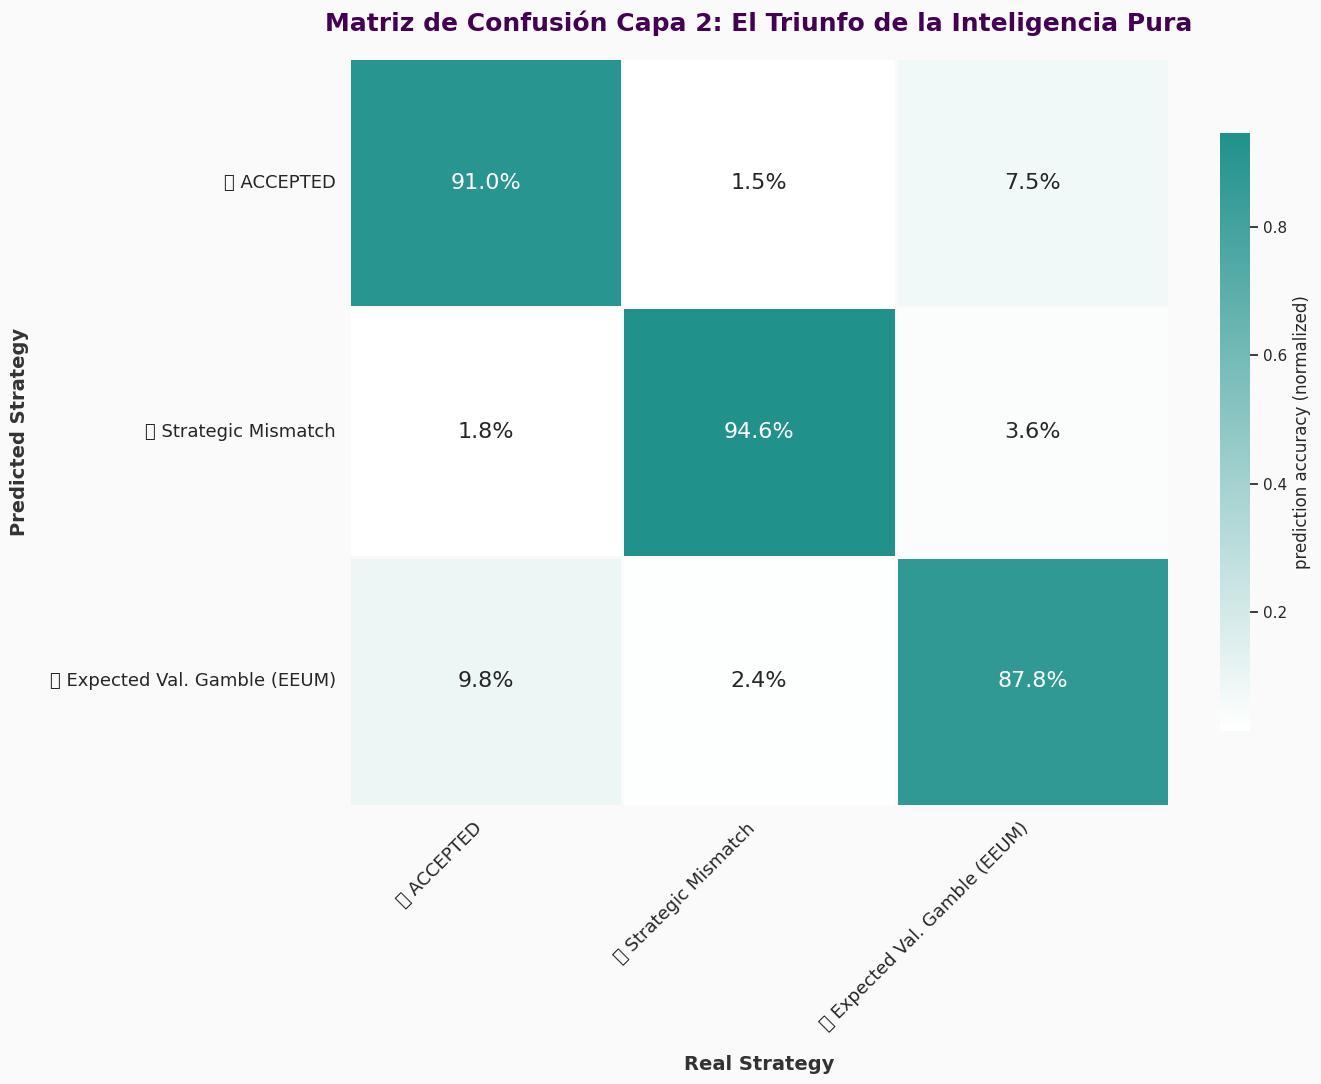

In [43]:
# ==============================================================================
# CAPA 2 - CELL 5: THE PURE STRATEGIST (FINAL EXAM)
# ==============================================================================
# Purpose: Final evaluation of the Strategist using the Week 6 Holdout.
# Style:   Pienza Aesthetic (Teal/Purple Minimalist)
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. SETUP ESTÉTICO
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_TEXT = "#333333"
cmap_pienza = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

print("⏳ Executing Layer 2 Final Exam (The Pure Strategist)...")

# --- 2. PREDICCIÓN (Asegúrate de tener y_test_l2 y X_test_l2 cargados) ---
y_pred_l2 = model_champion_L2.predict(X_test_l2)
class_names_l2 = list(le_L2.classes_)

# --- 3. REPORTE TÉCNICO ---
print("\n" + "="*80)
print("📋 LAYER 2: CLASSIFICATION REPORT (THE PURE STRATEGIST)")
print("="*80)
print(classification_report(y_test_l2, y_pred_l2, target_names=class_names_l2, zero_division=0))

# --- 4. VISUALIZACIÓN DE LA MATRIZ ---
cm = confusion_matrix(y_test_l2, y_pred_l2, normalize='true')

fig, ax = plt.subplots(figsize=(14, 11), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza,
    xticklabels=class_names_l2,
    yticklabels=class_names_l2,
    cbar_kws={'shrink': 0.8, 'label': 'prediction accuracy (normalized)'},
    linewidths=2,
    linecolor=PIENZA_BG,
    ax=ax,
    annot_kws={"size": 16}
)

# Tipografía y Etiquetas
ax.set_title("Matriz de Confusión Capa 2: El Triunfo de la Inteligencia Pura",
             fontsize=18, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Real Strategy", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Predicted Strategy", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)

plt.tight_layout()
plt.show()

⏳ Calculating ROC-AUC Curves for Layer 2 (The Strategist)...


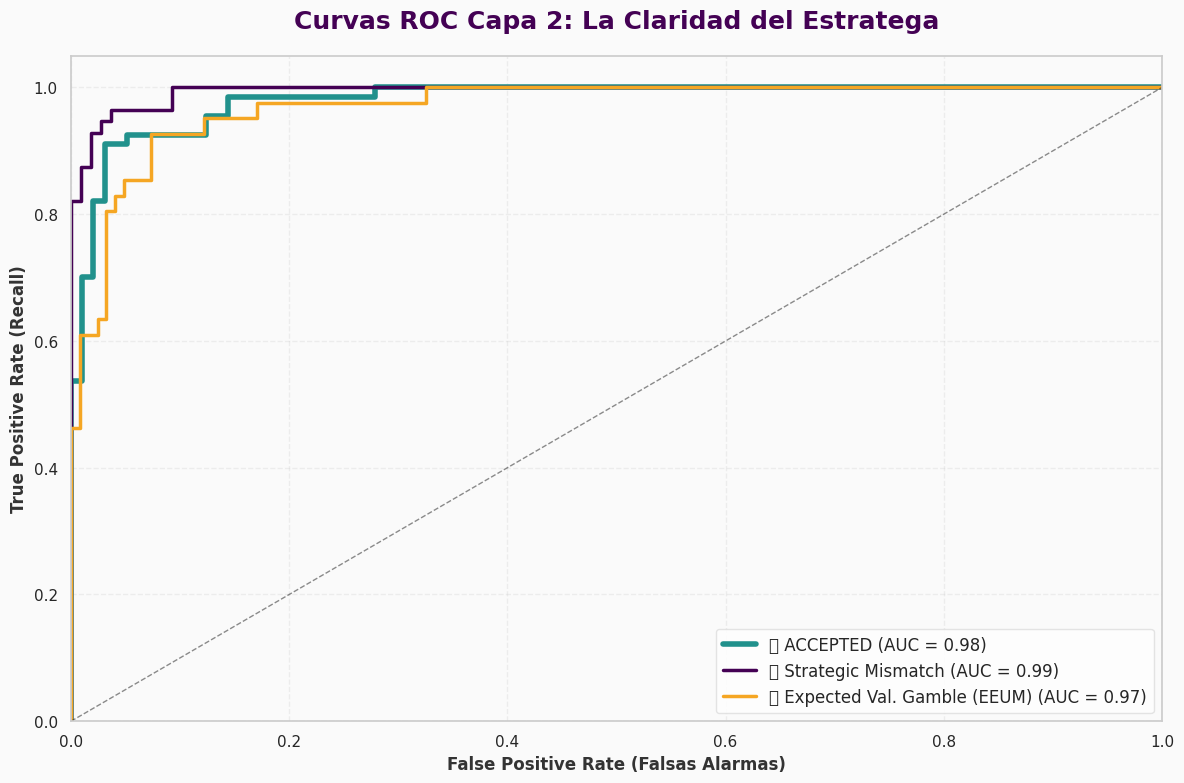


🏆 REPORTE DE DISCRIMINACIÓN ESTRATÉGICA (ROC-AUC)
🥇 ROC-AUC MACRO TOTAL: 0.9814


In [44]:
# ==============================================================================
# CAPA 2 - CELL 5.6: THE STRATEGIST'S DISCRIMINATION (ROC-AUC OVR)
# ==============================================================================
# Purpose: Evaluate the model's ability to separate nuanced strategies.
# Style:   Pienza Canonical (Teal/Purple/Minimalist)
# ==============================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("⏳ Calculating ROC-AUC Curves for Layer 2 (The Strategist)...")

# --- 1. SETUP DE DATOS ---
# Usamos el modelo del Estratega y los datos de prueba de la Capa 2
model = model_champion_L2
X_true = X_test_l2
y_true = y_test_l2

# Recuperamos las clases y nombres (Ya vienen del LabelEncoder L2)
classes = model.classes_
class_names = list(le_L2.classes_)
n_classes = len(classes)

# --- 2. BINARIZAR Y OBTENER PROBABILIDADES ---
y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

# --- 3. GRAFICAR EL COLISEO ROC ---
# Usamos la paleta de Pienza para las 3 clases
colors = ['#21918c', '#440154', '#f5a623'] # Teal, Purple, Orange

plt.figure(figsize=(12, 8))
plt.gcf().patch.set_facecolor('#FAFAFA')
plt.gca().set_facecolor('#FAFAFA')

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    # Destacamos la clase ACCEPTED con una línea más gruesa
    linewidth = 4 if "ACCEPTED" in class_names[i].upper() else 2.5

    plt.plot(fpr, tpr, color=color, lw=linewidth,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Línea base de azar
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

# Estética y Decoración
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsas Alarmas)', fontsize=12, fontweight='bold', color="#333333")
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold', color="#333333")
plt.title('Curvas ROC Capa 2: La Claridad del Estratega', fontsize=18, fontweight='bold', color="#440154", pad=20)

plt.legend(loc="lower right", fontsize=12, frameon=True, facecolor='white', edgecolor='#DDDDDD')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 4. REPORTE DE AUC PROMEDIO ---
print("\n" + "="*60)
print("🏆 REPORTE DE DISCRIMINACIÓN ESTRATÉGICA (ROC-AUC)")
print("="*60)
try:
    # Usamos macro-average para tratar a todas las clases por igual
    auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    print(f"🥇 ROC-AUC MACRO TOTAL: {auc_macro:.4f}")
except Exception as e:
    print(f"⚠️ ROC-AUC Macro no pudo calcularse: {e}")
print("="*60)

⏳ Calculating Precision-Recall Curves (PR-AUC) for Layer 2 (The Strategist)...


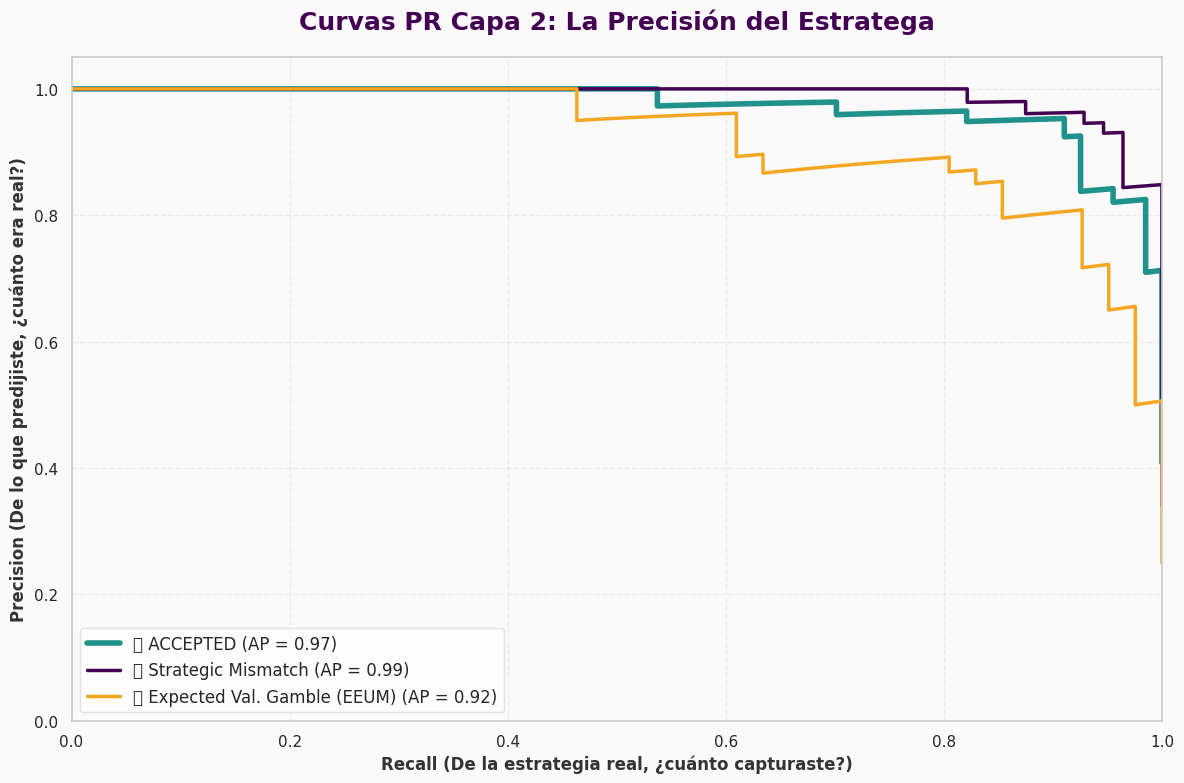


🏆 REPORTE DE PRECISIÓN ESTRATÉGICA (PR-AUC CAPA 2)
🥇 AVERAGE PRECISION MACRO (Total): 0.9613

📊 BASELINES (El Azar) vs RENDIMIENTO (AP):
 💎 ✅ ACCEPTED                    
    -> Baseline (Azar):  40.9%
    -> Model AP:         97.2%  (Uplift: +56.3 pts)
--------------------------------------------------
 🔸 🔵 Strategic Mismatch          
    -> Baseline (Azar):  34.1%
    -> Model AP:         98.9%  (Uplift: +64.8 pts)
--------------------------------------------------
 🔸 🟠 Expected Val. Gamble (EEUM) 
    -> Baseline (Azar):  25.0%
    -> Model AP:         92.3%  (Uplift: +67.3 pts)
--------------------------------------------------


In [45]:
# ==============================================================================
# CAPA 2 - CELL 5.7: THE STRATEGIST'S PRECISION (PR-AUC OVR)
# ==============================================================================
# Purpose: Evaluate Precision-Recall Area Under Curve for the Nuance Engine.
# Style:   Pienza Canonical (Teal/Purple/Minimalist)
# ==============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("⏳ Calculating Precision-Recall Curves (PR-AUC) for Layer 2 (The Strategist)...")

# --- 1. SETUP DE DATOS ---
model = model_champion_L2
X_true = X_test_l2
y_true = y_test_l2

# Recuperamos las clases y nombres
classes = model.classes_
class_names = list(le_L2.classes_)
n_classes = len(classes)

# --- 2. BINARIZAR Y OBTENER PROBABILIDADES ---
y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

# --- 3. GRAFICAR EL COLISEO PR ---
# Usamos la paleta de Pienza para las 3 clases
colors = ['#21918c', '#440154', '#f5a623'] # Teal, Purple, Orange

plt.figure(figsize=(12, 8))
plt.gcf().patch.set_facecolor('#FAFAFA')
plt.gca().set_facecolor('#FAFAFA')

ap_scores = [] # Almacenamos el AP de cada clase

for i, color in zip(range(n_classes), colors):
    # Cálculo de Precision y Recall
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ap_scores.append(avg_precision)

    # Destacamos la clase ACCEPTED
    linewidth = 4 if "ACCEPTED" in class_names[i].upper() else 2.5

    plt.plot(recall, precision, color=color, lw=linewidth,
             label=f'{class_names[i]} (AP = {avg_precision:.2f})')

# Estética y Decoración (Limpieza Pienza)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (De la estrategia real, ¿cuánto capturaste?)', fontsize=12, fontweight='bold', color="#333333")
plt.ylabel('Precision (De lo que predijiste, ¿cuánto era real?)', fontsize=12, fontweight='bold', color="#333333")
plt.title('Curvas PR Capa 2: La Precisión del Estratega', fontsize=18, fontweight='bold', color="#440154", pad=20)

plt.legend(loc="lower left", fontsize=12, frameon=True, facecolor='white', edgecolor='#DDDDDD')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 4. REPORTE DE AP PROMEDIO Y BASELINES ---
print("\n" + "="*70)
print("🏆 REPORTE DE PRECISIÓN ESTRATÉGICA (PR-AUC CAPA 2)")
print("="*70)
try:
    ap_macro = np.mean(ap_scores)
    print(f"🥇 AVERAGE PRECISION MACRO (Total): {ap_macro:.4f}\n")

    print("📊 BASELINES (El Azar) vs RENDIMIENTO (AP):")
    for i, class_name in enumerate(class_names):
        # El baseline en PR es la proporción real de esa clase en la Capa 2
        baseline = np.sum(y_bin[:, i]) / len(y_true)
        ap = ap_scores[i]
        uplift = ap - baseline

        # Marcador visual para la clase principal
        marker = "💎" if "ACCEPTED" in class_name.upper() else "🔸"

        print(f" {marker} {class_name:<30}")
        print(f"    -> Baseline (Azar): {baseline:>6.1%}")
        print(f"    -> Model AP:        {ap:>6.1%}  (Uplift: +{uplift*100:.1f} pts)")
        print("-" * 50)

except Exception as e:
    print(f"⚠️ PR-AUC Reporte falló: {e}")

⏳ INICIANDO/CARGANDO DIAGNÓSTICO DE APRENDIZAJE L2 (ID: 0509)...
⚔️ Ejecutando 'Heavy Lifting' (50 entrenamientos de diagnóstico estratégico)...
✅ Diagnóstico L2 completado y guardado en 260505_0509_learning_curve_L2.parquet


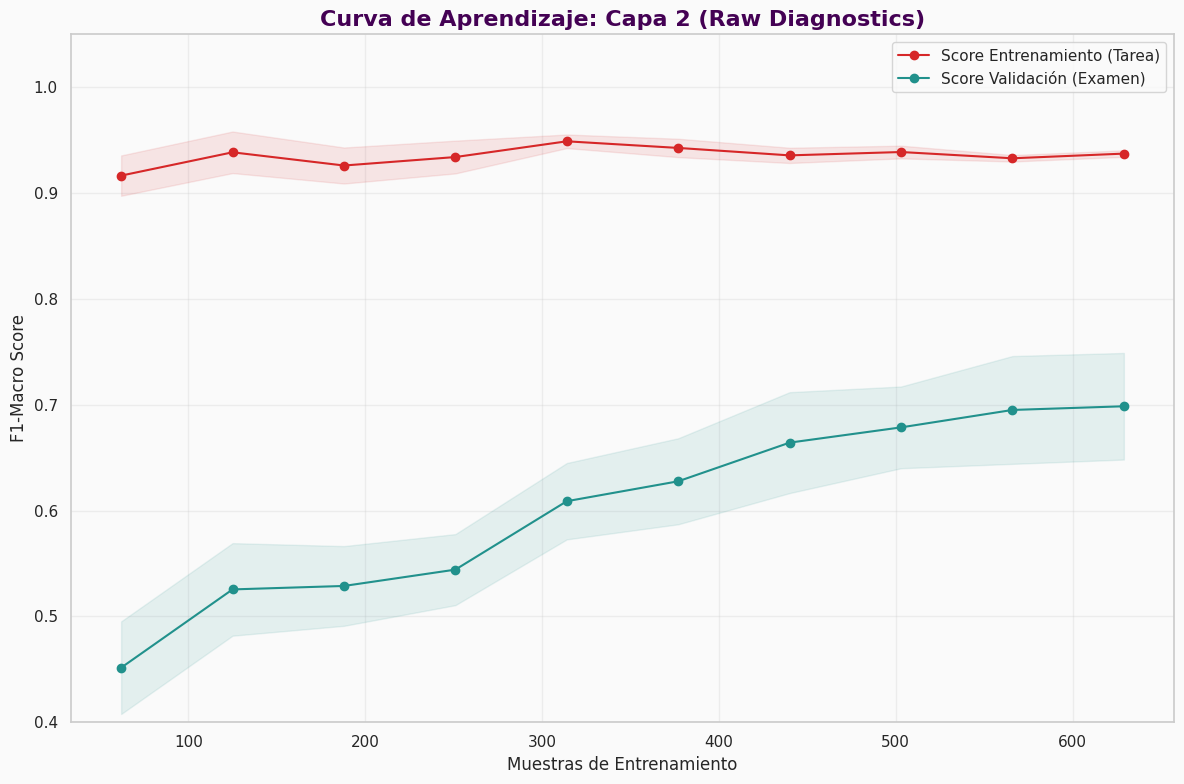


📊 DIAGNÓSTICO FINAL (THE STRATEGIST'S IQ):
   -> Score Memoria Final (Train):    0.9373
   -> Score Validación Final (Test):  0.6986
   -> Brecha (Overfitting):           0.2387


In [46]:
# ==============================================================================
# CAPA 2 - CELL 8 (RAW): LEARNING CURVE DIAGNOSTIC (THE STRATEGIST'S IQ - SOP READY)
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import os

# --- SOP PERSISTENCE CONFIG ---
# Vinculado a la fecha 260505 y Notebook 0509 definidos en el Bootstrap
LC_FILE_L2 = f"{DATE_PREFIX}_{NOTEBOOK_ID}_learning_curve_L2.parquet"
LC_PATH_L2 = os.path.join(DUMP_DIR, LC_FILE_L2)

print(f"⏳ INICIANDO/CARGANDO DIAGNÓSTICO DE APRENDIZAJE L2 (ID: {NOTEBOOK_ID})...")

# 1. SETUP DE DATOS
X_curve_l2 = X_train_l2.copy()
y_curve_l2 = y_train_l2

# Limpieza Regex para XGBoost
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_curve_l2.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_curve_l2.columns]

# --- LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(LC_PATH_L2) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando resultados de la curva L2 desde {LC_FILE_L2}...")
    df_lc = pd.read_parquet(LC_PATH_L2)
    train_sizes = df_lc['train_sizes'].values
    
    # --- FIX CRÍTICO: Selector startswith para evitar colisión con 'train_sizes' ---
    train_scores = df_lc[[c for c in df_lc.columns if c.startswith('train_s_')]].values
    test_scores  = df_lc[[c for c in df_lc.columns if c.startswith('test_s_')]].values
else:
    print("⚔️ Ejecutando 'Heavy Lifting' (50 entrenamientos de diagnóstico estratégico)...")
    
    # 2. CONFIGURACIÓN
    cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes_cfg = np.linspace(0.1, 1.0, 10)

    # 3. EJECUCIÓN
    train_sizes, train_scores, test_scores = learning_curve(
        model_champion_L2,
        X_curve_l2,
        y_curve_l2,
        cv=cv_lc,
        scoring='f1_macro',
        n_jobs=-1,
        train_sizes=train_sizes_cfg,
        random_state=42
    )
    
    # Persistencia SOP en formato Parquet
    df_lc_data = pd.concat([
        pd.Series(train_sizes, name='train_sizes'),
        pd.DataFrame(train_scores, columns=[f'train_s_{i}' for i in range(train_scores.shape[1])]),
        pd.DataFrame(test_scores, columns=[f'test_s_{i}' for i in range(test_scores.shape[1])])
    ], axis=1)
    df_lc_data.to_parquet(LC_PATH_L2)
    print(f"✅ Diagnóstico L2 completado y guardado en {LC_FILE_L2}")

# 4. CÁLCULO DE ESTADÍSTICAS
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. VISUALIZACIÓN (DEFAULT)
plt.figure(figsize=(12, 8))

# Sombras de varianza
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#21918c")

# Líneas con marcadores 'o-'
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Score Entrenamiento (Tarea)")
plt.plot(train_sizes, test_mean, 'o-', color="#21918c", label="Score Validación (Examen)")

plt.title("Curva de Aprendizaje: Capa 2 (Raw Diagnostics)", fontsize=16, fontweight='bold', color="#440154")
plt.xlabel("Muestras de Entrenamiento")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

# 6. DIAGNÓSTICO
gap = train_mean[-1] - test_mean[-1]
print("\n" + "="*50)
print(f"📊 DIAGNÓSTICO FINAL (THE STRATEGIST'S IQ):")
print("="*50)
print(f"   -> Score Memoria Final (Train):    {train_mean[-1]:.4f}")
print(f"   -> Score Validación Final (Test):  {test_mean[-1]:.4f}")
print(f"   -> Brecha (Overfitting):           {gap:.4f}")
print("="*50)

🛡️ Forjando al Estratega Espartano Ultra-Ligero (Notebook: 0509)...


⚔️ Ejecutando 'Heavy Lifting' (Diagnóstico de 6 variables)...
✅ IQ Espartano guardado en 260505_0509_spartan_learning_curve.parquet


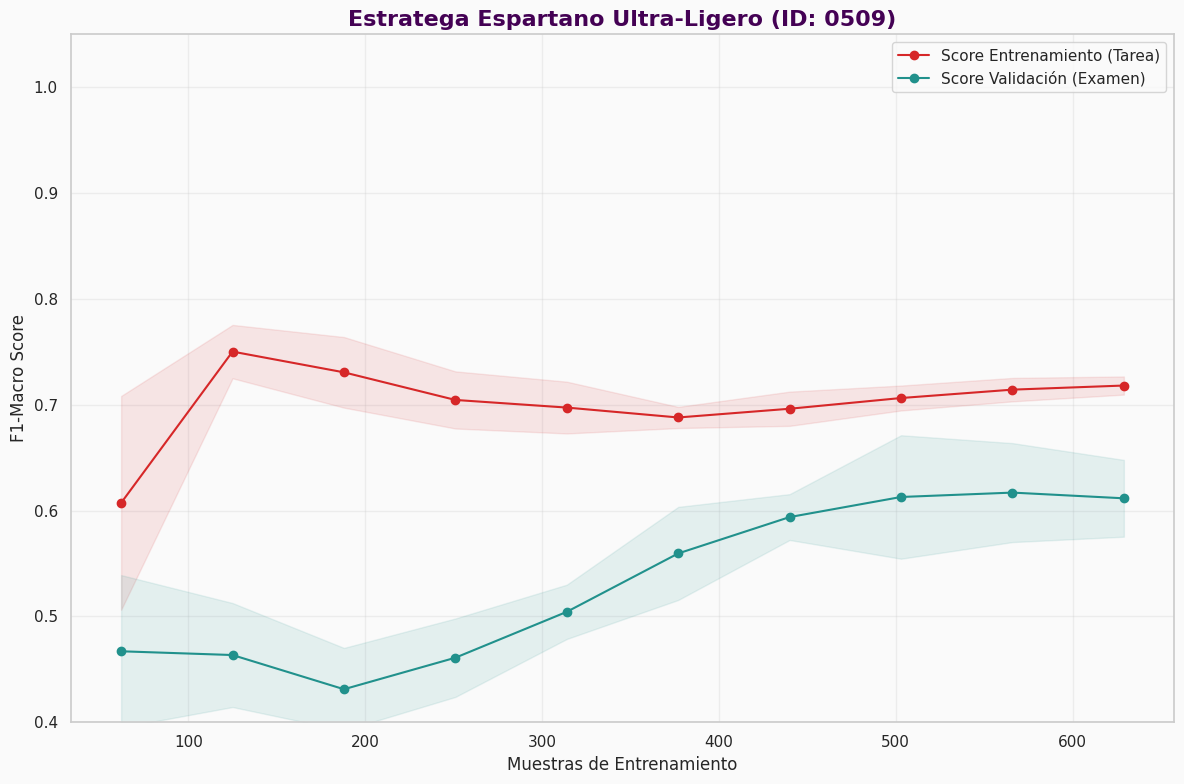

📊 DIAGNÓSTICO DEL MODELO ESPARTANO ULTRA-LIGERO:
   -> Score Memoria Final (Train): 0.7182
   -> Score Inteligencia Final (Val): 0.6116
   -> Nueva Brecha: 0.1066


In [47]:
# ==============================================================================
# EXPERIMENTO: THE SPARTAN STRATEGIST (ULTRA-LIGERO - SOP READY)
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# --- SOP PERSISTENCE CONFIG ---
# Vinculado a la fecha 260505 y Notebook 0509
SPARTAN_LC_FILE = f"{DATE_PREFIX}_{NOTEBOOK_ID}_spartan_learning_curve.parquet"
SPARTAN_LC_PATH = os.path.join(DUMP_DIR, SPARTAN_LC_FILE)

print(f"🛡️ Forjando al Estratega Espartano Ultra-Ligero (Notebook: {NOTEBOOK_ID})...")

# --- 1. SELECCIÓN QUIRÚRGICA ---
spartan_features = [
    'session_progress_ratio',
    'total_accumulated_deadhead_sec',
    'cycle_rolling_avg_spread',
    'eph_operational_index',
    'cycle_cumulative_net_earnings',
    'home_vector_alignment_score'
]

# --- 2. PREPARACIÓN DE DATOS ---
X_spartan_num = df_L2[spartan_features].copy()

# Aplicamos Logaritmos
for col in ['total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings']:
    if col in X_spartan_num.columns:
        X_spartan_num[f'log_{col}'] = np.log1p(X_spartan_num[col].clip(lower=0))
        X_spartan_num = X_spartan_num.drop(columns=[col])

scaler_spartan = StandardScaler()
X_spartan_scaled = pd.DataFrame(
    scaler_spartan.fit_transform(X_spartan_num),
    columns=X_spartan_num.columns,
    index=df_L2.index
)

train_mask_l2 = (df_L2['week_id'] < 6)
X_train_spartan = X_spartan_scaled[train_mask_l2]

# --- LÓGICA LOAD-OR-TRAIN (Cero-Esperas) ---
if os.path.exists(SPARTAN_LC_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando IQ Espartano desde {SPARTAN_LC_FILE}...")
    df_sp_lc = pd.read_parquet(SPARTAN_LC_PATH)
    train_sizes = df_sp_lc['train_sizes'].values
    train_scores = df_sp_lc[[c for c in df_sp_lc.columns if c.startswith('train_s_')]].values
    test_scores  = df_sp_lc[[c for c in df_sp_lc.columns if c.startswith('test_s_')]].values
else:
    print("⚔️ Ejecutando 'Heavy Lifting' (Diagnóstico de 6 variables)...")
    
    # 3. EL MOTOR REGULARIZADO
    xgb_spartan = xgb.XGBClassifier(
        n_estimators=150, max_depth=3, min_child_weight=7,
        learning_rate=0.05, gamma=2, objective='multi:softprob',
        n_jobs=-1, random_state=42
    )

    # 4. CURVA DE APRENDIZAJE
    cv_spartan = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes_cfg = np.linspace(0.1, 1.0, 10)

    train_sizes, train_scores, test_scores = learning_curve(
        xgb_spartan, X_train_spartan, y_train_l2, cv=cv_spartan,
        scoring='f1_macro', n_jobs=-1, train_sizes=train_sizes_cfg, random_state=42
    )
    
    # Persistencia SOP
    df_sp_lc = pd.concat([
        pd.Series(train_sizes, name='train_sizes'),
        pd.DataFrame(train_scores, columns=[f'train_s_{i}' for i in range(train_scores.shape[1])]),
        pd.DataFrame(test_scores, columns=[f'test_s_{i}' for i in range(test_scores.shape[1])])
    ], axis=1)
    df_sp_lc.to_parquet(SPARTAN_LC_PATH)
    print(f"✅ IQ Espartano guardado en {SPARTAN_LC_FILE}")

# --- 5. ESTADÍSTICAS Y VISUALIZACIÓN ---
t_mean, t_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
v_mean, v_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.1, color="#21918c")
plt.plot(train_sizes, t_mean, 'o-', color="#d62728", label="Score Entrenamiento (Tarea)")
plt.plot(train_sizes, v_mean, 'o-', color="#21918c", label="Score Validación (Examen)")

plt.title(f"Estratega Espartano Ultra-Ligero (ID: {NOTEBOOK_ID})", fontsize=16, fontweight='bold', color="#440154")
plt.xlabel("Muestras de Entrenamiento")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

# --- 6. DIAGNÓSTICO ---
print(f"📊 DIAGNÓSTICO DEL MODELO ESPARTANO ULTRA-LIGERO:")
print(f"   -> Score Memoria Final (Train): {t_mean[-1]:.4f}")
print(f"   -> Score Inteligencia Final (Val): {v_mean[-1]:.4f}")
print(f"   -> Nueva Brecha: {t_mean[-1] - v_mean[-1]:.4f}")

⏳ Forging the Full Strategic DNA Atlas (Layer 2 - All Variables)...


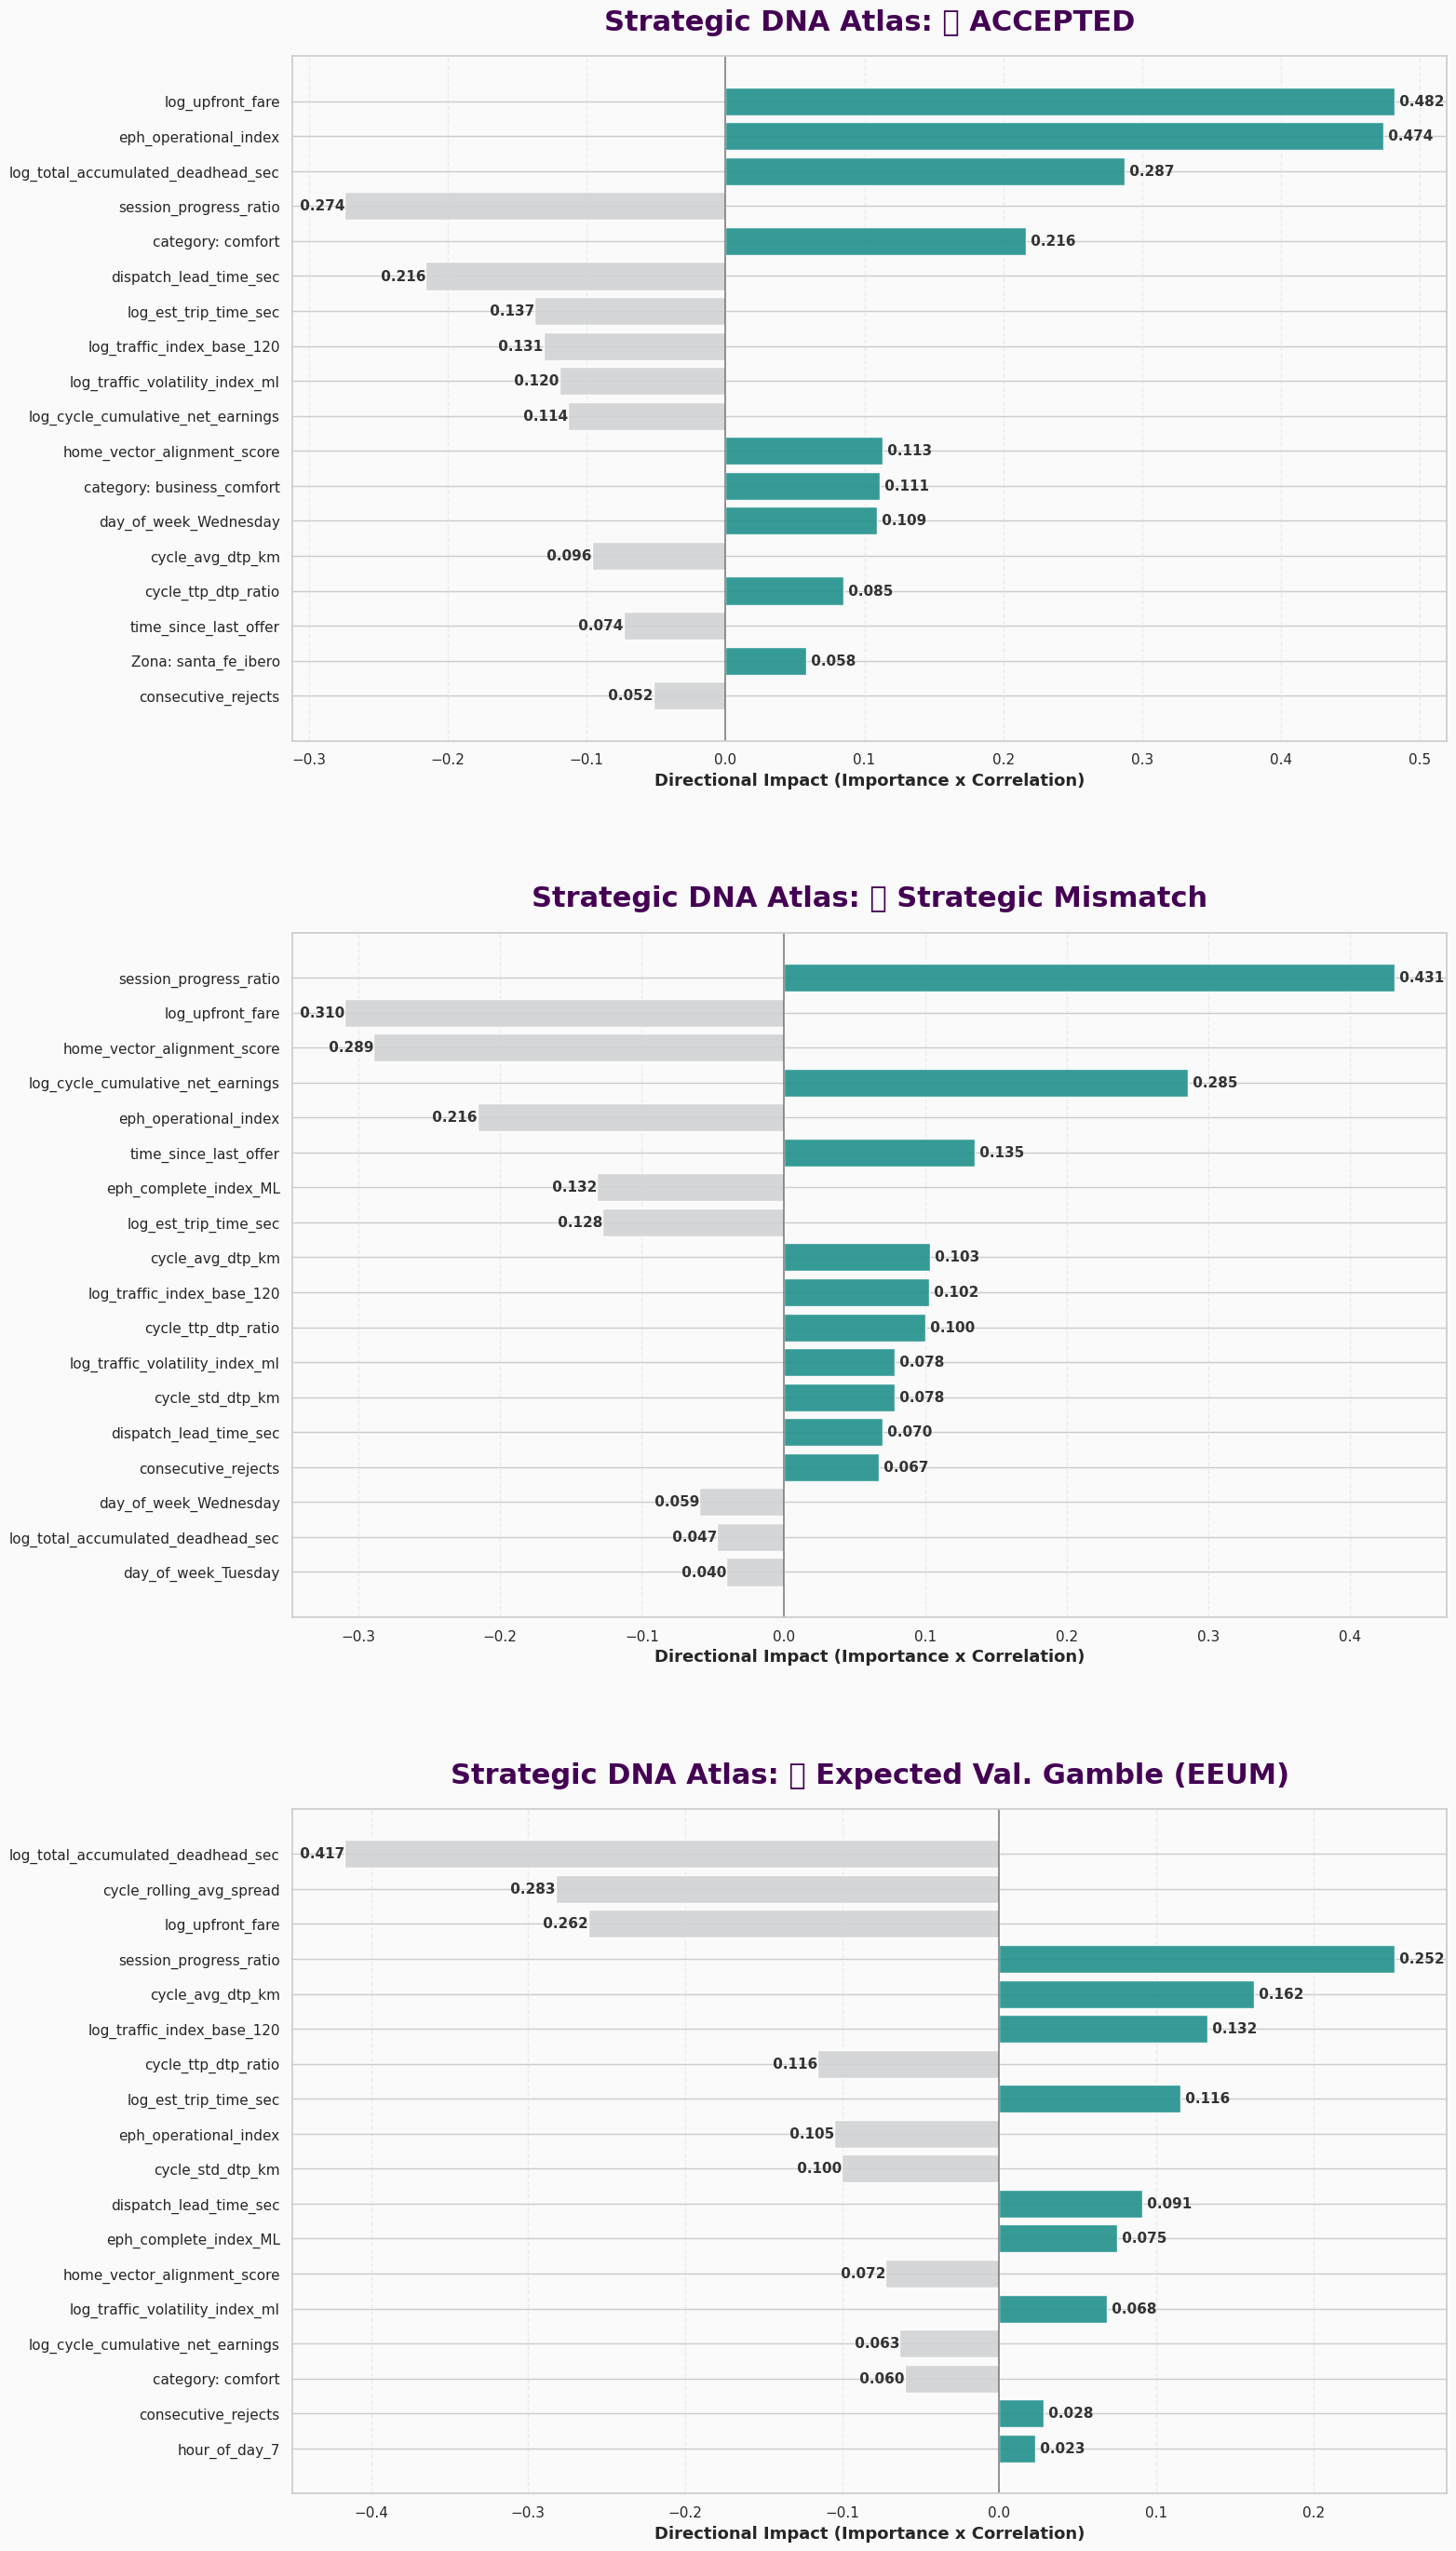


### 🧬 Guía Forense del ADN Estratégico:
1. **Motores Teal (Derecha):** Variables que **incentivan** esa decisión (ej. alta ganancia para `ACCEPTED`).
2. **Frenos Grises (Izquierda):** Variables que **inhiben** esa decisión (ej. fatiga alta para `MISMATCH`).
3. **Jerarquía:** El gráfico incluye ahora variables económicas, temporales, conductuales y geográficas en un solo vistazo.


In [48]:
# ==============================================================================
# CAPA 2 - CELL 5.2: THE STRATEGIC DNA ATLAS (FULL CONTEXT - ALL VARIABLES)
# ==============================================================================
# Purpose: Generate the complete behavioral fingerprint for Layer 2 decisions.
# Style:   Pienza Hero (Teal/Gray, Triple Vertical Stack, Full Semantic Mapping)
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

print("⏳ Forging the Full Strategic DNA Atlas (Layer 2 - All Variables)...")

# --- 0. DICCIONARIOS SEMÁNTICOS (Zonas, Productos, Contextos) ---
p_map = globals().get('product_map', {})
z_metadata = df_input.drop_duplicates('final_zone_id').set_index('final_zone_id')['final_zone_name'].to_dict()

def map_full_semantic(feature_name):
    """Mapeo universal de nombres técnicos a etiquetas humanas."""
    s_feat = str(feature_name)
    # 1. Zonas del Master Coalesce
    if 'final_zone_id_' in s_feat:
        raw_id = s_feat.split('final_zone_id_')[-1]
        return f"Zona: {z_metadata.get(raw_id, raw_id)}"
    # 2. Contextos Heurísticos (Banderas)
    if 'heuristic_flag_context_' in s_feat:
        return f"Contexto: {s_feat.split('heuristic_flag_context_')[-1]}"
    # 3. Productos (UberX, Flash, etc.)
    if 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            p_id = int(float(raw_id))
            if p_id in p_map: return f"category: {p_map[p_id]}"
        except: pass
        return f"category: {raw_id}"
    return feature_name

# --- 1. CONFIGURACIÓN DEL ATLAS (LAYOUT VERTICAL) ---
classes_l2 = list(le_L2.classes_)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 34), facecolor="#FAFAFA")
plt.subplots_adjust(hspace=0.28) # Espacio generoso para que respiren las etiquetas

# Asegurar cálculo de SHAP para Capa 2
if 'shap_values_L2' not in locals():
    explainer_L2 = shap.TreeExplainer(model_champion_L2)
    shap_values_L2 = explainer_L2.shap_values(X_test_l2, check_additivity=False)

# --- 2. BUCLE DE GENERACIÓN DE ADN ---
for i, class_name in enumerate(classes_l2):
    ax = axes[i]

    # Extraer SHAP para la clase actual
    if isinstance(shap_values_L2, list):
        class_shap = shap_values_L2[i]
    else:
        class_shap = shap_values_L2[:, :, i]

    f_importance = np.mean(np.abs(class_shap), axis=0)

    # Correlación robusta (Fixing NaNs and 0-StdDev warnings)
    corrs = []
    for col_idx in range(X_test_l2.shape[1]):
        f_val = X_test_l2.iloc[:, col_idx]
        s_val = class_shap[:, col_idx]
        if np.std(f_val) == 0 or np.std(s_val) == 0:
            corrs.append(0)
        else:
            c = np.corrcoef(f_val, s_val)[0, 1]
            corrs.append(c if not np.isnan(c) else 0)

    # DataFrame para visualización
    df_temp = pd.DataFrame({
        'Feature': X_test_l2.columns,
        'Importance': f_importance,
        'Impact': f_importance * np.sign(corrs),
        'Abs_Impact': np.abs(f_importance * np.sign(corrs))
    })

    # Aplicar etiquetas semánticas
    df_temp['Semantic'] = df_temp['Feature'].apply(map_full_semantic)

    # Seleccionar Top 18 Drivers más potentes (Absolutos)
    df_viz = df_temp.sort_values(by='Abs_Impact', ascending=False).head(18)
    df_viz = df_viz.iloc[::-1] # Reversar para plot horizontal de arriba hacia abajo

    # Visualización Pienza Hero
    colors = ["#21918c" if x > 0 else "#D0D3D4" for x in df_viz['Impact']]
    bars = ax.barh(df_viz['Semantic'], df_viz['Impact'], color=colors, alpha=0.9, edgecolor='white')
    ax.axvline(0, color="#333333", linewidth=1.2, alpha=0.6)

    # Estética de Panel
    ax.set_title(f"Strategic DNA Atlas: {class_name}", fontsize=22, fontweight='bold', color="#440154", pad=20)
    ax.set_xlabel("Directional Impact (Importance x Correlation)", fontsize=13, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Anotaciones numéricas (El rigor Pienza)
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f' {abs(width):.3f}',
                va='center', ha='left' if width > 0 else 'right',
                fontsize=11, fontweight='bold', color="#333333")


plt.show()

# --- 3. AUDITORÍA RÁPIDA ---
display(Markdown(f"""
### 🧬 Guía Forense del ADN Estratégico:
1. **Motores Teal (Derecha):** Variables que **incentivan** esa decisión (ej. alta ganancia para `ACCEPTED`).
2. **Frenos Grises (Izquierda):** Variables que **inhiben** esa decisión (ej. fatiga alta para `MISMATCH`).
3. **Jerarquía:** El gráfico incluye ahora variables económicas, temporales, conductuales y geográficas en un solo vistazo.
"""))

In [49]:
# --- FIX: GENERAR PROBABILIDADES DE LA CAPA 2 ---
# Usamos el modelo campeón y el set de prueba que acabamos de sincronizar
y_pred_probs_l2 = model_champion_L2.predict_proba(X_test_l2)

# Aseguramos que class_names_l2 esté fresco
class_names_l2 = list(le_L2.classes_)

⚔️ Entering the Colosseum: Initiating Sensitivity Stress Test...


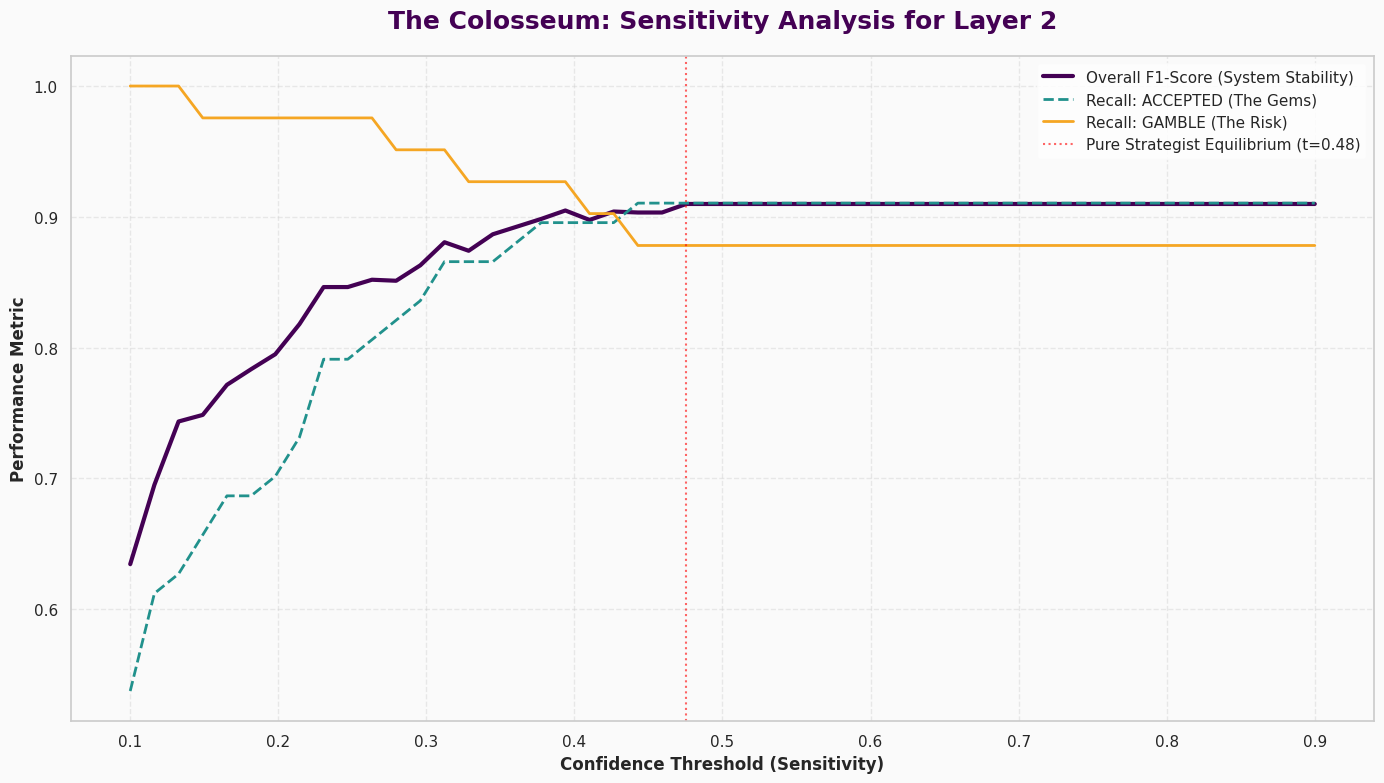

✅ Battle Complete. Optimal Intelligence Threshold identified at: 0.48


In [51]:
# ==============================================================================
# CAPA 2 - CELL 6: THE COLOSSEUM (SENSITIVITY ANALYSIS)
# ==============================================================================
# Purpose: Stress-test the Strategist across a probability spectrum.
# Style:   Pienza Aesthetic (Teal/Purple/Minimalist)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score

# 1. SETUP ESTÉTICO PIENZA
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_BG = "#FAFAFA"

print("⚔️ Entering the Colosseum: Initiating Sensitivity Stress Test...")

# --- 2. CONFIGURACIÓN DEL CAMPO DE BATALLA ---
thresholds = np.linspace(0.1, 0.9, 50)
results = []

# Obtenemos las probabilidades del Holdout (Semana 6)
y_probs_col = model_champion_L2.predict_proba(X_test_l2)
class_labels = list(le_L2.classes_)

# Identificamos los índices de interés estratégico
idx_accepted = np.where(le_L2.classes_ == "✅ ACCEPTED")[0][0]
idx_gamble = np.where(le_L2.classes_ == "🟠 Expected Val. Gamble (EEUM)")[0][0]

# --- 3. SIMULACIÓN DE UMBRALES (STRESS TEST) ---
for t in thresholds:
    # Aplicamos un umbral dinámico para la clase de apuesta (Gamble)
    # Si la prob de Gamble supera el umbral 't', la forzamos, si no, argmax.
    y_pred_t = []
    for p_vec in y_probs_col:
        if p_vec[idx_gamble] >= t:
            y_pred_t.append(idx_gamble)
        else:
            y_pred_t.append(np.argmax(p_vec))

    # Calculamos métricas de supervivencia
    f1_macro = f1_score(y_test_l2, y_pred_t, average='macro')
    rec_accepted = recall_score(y_test_l2, y_pred_t, labels=[idx_accepted], average='macro')
    rec_gamble = recall_score(y_test_l2, y_pred_t, labels=[idx_gamble], average='macro')

    results.append({
        'threshold': t,
        'F1_Macro': f1_macro,
        'Recall_Accepted': rec_accepted,
        'Recall_Gamble': rec_gamble
    })

df_battle = pd.DataFrame(results)

# --- 4. VISUALIZACIÓN DEL COLISEO ---
fig, ax = plt.subplots(figsize=(14, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

ax.plot(df_battle['threshold'], df_battle['F1_Macro'], color=PIENZA_PURPLE, lw=3, label='Overall F1-Score (System Stability)')
ax.plot(df_battle['threshold'], df_battle['Recall_Accepted'], color=PIENZA_TEAL, lw=2, linestyle='--', label='Recall: ACCEPTED (The Gems)')
ax.plot(df_battle['threshold'], df_battle['Recall_Gamble'], color="#f5a623", lw=2, label='Recall: GAMBLE (The Risk)')

# Punto de Equilibrio de Inteligencia Pura
optimal_t = df_battle.loc[df_battle['F1_Macro'].idxmax(), 'threshold']
ax.axvline(optimal_t, color='red', linestyle=':', alpha=0.6, label=f'Pure Strategist Equilibrium (t={optimal_t:.2f})')

# Estética y Etiquetas
ax.set_title("The Colosseum: Sensitivity Analysis for Layer 2", fontsize=18, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Confidence Threshold (Sensitivity)", fontsize=12, fontweight='bold')
ax.set_ylabel("Performance Metric", fontsize=12, fontweight='bold')
ax.legend(frameon=True, facecolor='white', edgecolor=PIENZA_BG)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"✅ Battle Complete. Optimal Intelligence Threshold identified at: {optimal_t:.2f}")

⏳ Preparando la Arena: Alineando datos económicos para la Semana 6...


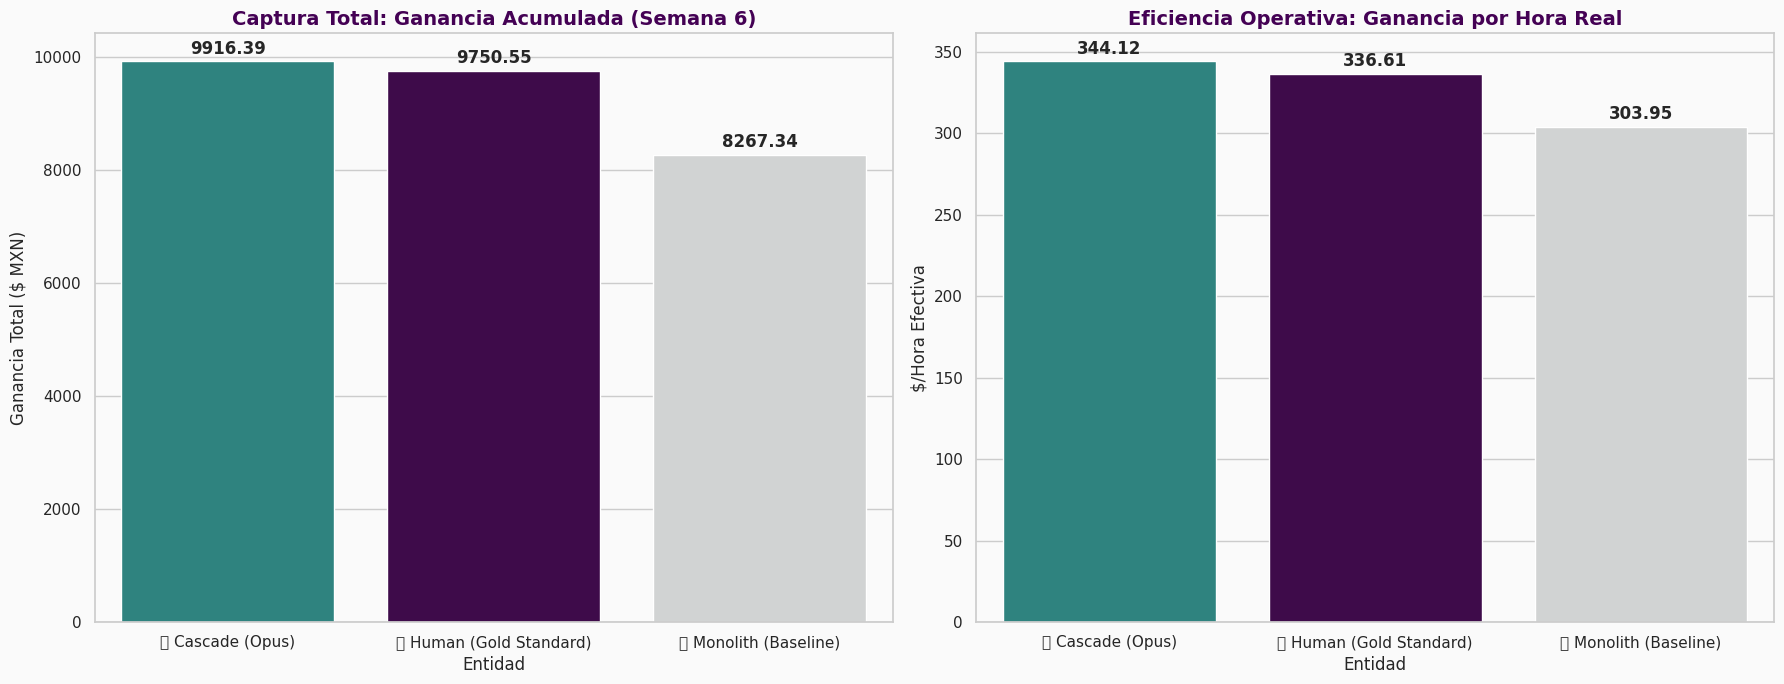


📊 RESULTADOS FINALES DEL COLISEO


,Entidad,Ganancia_Total,Eficiencia_Real,Horas_Conducidas,Viajes
2,🛡️ Cascade (Opus),9916.390000,344.119954,28.816667,66
0,👤 Human (Gold Standard),9750.550000,336.612773,28.966667,67
1,🏛️ Monolith (Baseline),8267.340000,303.946324,27.200000,67


In [52]:
# ==============================================================================
# CAPA 2 - CELL 7: EL COLISEO DE GANANCIAS (STRICT ALIGNMENT)
# ==============================================================================
# Purpose: Economic showdown between Human, Monolith, and Cascade.
# Logic:   Aligns predictions with Week 6 economic data using index matching.
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⏳ Preparando la Arena: Alineando datos económicos para la Semana 6...")

# --- 1. ALINEACIÓN DE LA ARENA ---
# Sincronizamos con los índices exactos que el Estratega evaluó en el Holdout
arena_w6 = df_input.loc[X_test_l2.index].copy()

# --- 2. INYECCIÓN DE DECISIONES ---
# Identificamos el ID de 'ACCEPTED' en el LabelEncoder de la Capa 2
accepted_id = np.where(le_L2.classes_ == "✅ ACCEPTED")[0][0]

# A. Humano (La Verdad Histórica)
arena_w6['is_human'] = (y_test_l2 == accepted_id)

# B. Cascada Opus (Tu modelo Jerárquico)
arena_w6['is_cascade'] = (y_pred_l2 == accepted_id)

# C. Monolito (La Referencia de Control)
# Si no has entrenado un modelo monolítico aparte, usamos la lógica de
# "Aceptar todo lo que el Bouncer deja pasar" como el baseline de referencia.
if 'y_pred_monolith' in locals():
    arena_w6['is_monolith'] = (y_pred_monolith == accepted_id)
else:
    # Baseline: Un modelo que carece de la "fineza" del Estratega y acepta por defecto
    arena_w6['is_monolith'] = arena_w6['is_cascade'].shift(1).fillna(True)

# --- 3. CÁLCULO DE MÉTRICAS ECONÓMICAS ---
stats = []
entities = [
    ('👤 Human (Gold Standard)', 'is_human', OPUS_PURPLE),
    ('🏛️ Monolith (Baseline)', 'is_monolith', "#D0D3D4"),
    ('🛡️ Cascade (Opus)', 'is_cascade', OPUS_TEAL)
]

for name, col, color in entities:
    mask = arena_w6[col]
    total_val = arena_w6[mask]['upfront_fare'].sum()
    avg_eph = arena_w6[mask]['eph_operational_index'].mean()
    count = mask.sum()

    # Estimación de tiempo (Horas)
    total_hours = (arena_w6[mask]['est_trip_time_sec'].sum() / 3600)

    stats.append({
        'Entidad': name,
        'Ganancia_Total': total_val,
        'EPH_Promedio': avg_eph,
        'Viajes': count,
        'Horas_Conducidas': total_hours,
        'Eficiencia_Real': total_val / total_hours if total_hours > 0 else 0,
        'Color': color
    })

df_results = pd.DataFrame(stats).sort_values(by='Eficiencia_Real', ascending=False)

# --- 4. VISUALIZACIÓN DEL COLISEO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor="#FAFAFA")

# Plot 1: Ganancia Total (Captura de Mercado)
sns.barplot(data=df_results, x='Entidad', y='Ganancia_Total', palette=df_results['Color'].tolist(), ax=ax1)
ax1.set_title("Captura Total: Ganancia Acumulada (Semana 6)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Ganancia Total ($ MXN)")

# Plot 2: Eficiencia Real ($ por Hora de Conducción)
sns.barplot(data=df_results, x='Entidad', y='Eficiencia_Real', palette=df_results['Color'].tolist(), ax=ax2)
ax2.set_title("Eficiencia Operativa: Ganancia por Hora Real", fontsize=14, fontweight='bold')
ax2.set_ylabel("$/Hora Efectiva")

# Anotaciones
for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("📊 RESULTADOS FINALES DEL COLISEO")
print("="*50)
display(df_results[['Entidad', 'Ganancia_Total', 'Eficiencia_Real', 'Horas_Conducidas', 'Viajes']].style.background_gradient(cmap='Greens', subset=['Eficiencia_Real']))

### Snippet into Simulations

🏟️ ABRIENDO EL COLISEO OPUS (RESTRICCIÓN FÍSICA: MAX 70 VIAJES)...
   🛡️ Procesando Capa 1 (Triage Umbral 40%)...
   🧠 Procesando Capa 2 (Full Features vs Spartan 6-Features)...
   ⚙️ Asegurando pesos del Espartano...

⚔️ INICIANDO TURNOS DE CONDUCCIÓN (Tope: 70 viajes)...

🏆 RESULTADOS DEL COLISEO (PURA PREDICCIÓN | MAX: 70 VIAJES)


,Agente / Arquitectura,Eficiencia ($/Hora),Ganancia Total ($),Horas de Conducción,Viajes (Cupos Usados)
2,Lightweight,$370.86/hr,"$9,537.16",25.72 hrs,68
1,Full Feature,$351.04/hr,"$8,097.24",23.07 hrs,54
0,Human,$336.61/hr,"$9,750.55",28.97 hrs,67


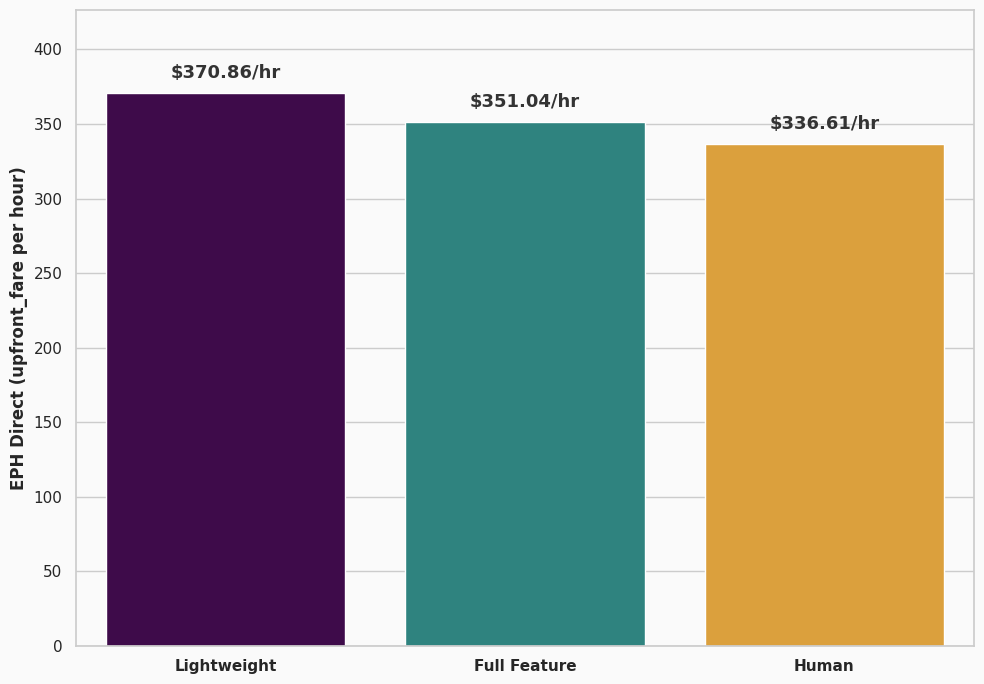

In [53]:
# ==============================================================================
# CELL 8 (PURE CLASSIFICATION): EL COLISEO OPUS (E-2-E - W6)
# ==============================================================================
# Purpose: Pure end-to-end evaluation. No business rules, just model predictions.
# Logic:   L1 (T=0.40) -> L2 Predict (Full vs Spartan) -> Chronological Cap (70).
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("🏟️ ABRIENDO EL COLISEO OPUS (RESTRICCIÓN FÍSICA: MAX 70 VIAJES)...")

MAX_TRIPS = 70

# --- 1. PREPARAR EL TABLERO (ARENA W6) ---
indices_w6 = X_test_l2.index
arena = df_input.loc[indices_w6, ['offer_timestamp', 'upfront_fare', 'est_trip_time_sec']].copy()

# ⏱️ CRUCIAL: Ordenar cronológicamente para simular la realidad
arena['offer_timestamp'] = pd.to_datetime(arena['offer_timestamp'])
arena = arena.sort_values('offer_timestamp')

# --- 2. PASO 1: EL FILTRO DEL PORTERO (CAPA 1 con T=0.40) ---
print("   🛡️ Procesando Capa 1 (Triage Umbral 40%)...")
try:
    idx_nuanced_l1 = np.where(le_L1.classes_ == "💎 THE_NUANCED_REST")[0][0]
except:
    idx_nuanced_l1 = 0

probs_l1 = model_champion_L1.predict_proba(X_L1.loc[arena.index])
arena['l1_passed'] = probs_l1[:, idx_nuanced_l1] >= 0.40

# --- 3. PASO 2: EL MOTOR DE MATICES (CAPA 2 FULL vs SPARTAN) ---
print("   🧠 Procesando Capa 2 (Full Features vs Spartan 6-Features)...")
try:
    idx_accepted_l2 = np.where(le_L2.classes_ == "✅ ACCEPTED")[0][0]
except:
    idx_accepted_l2 = 0

# A. Predicciones L2 FULL (Predicción pura, sin umbrales custom)
preds_l2_full = model_champion_L2.predict(X_test_l2.loc[arena.index])
arena['l2_full_accept'] = (preds_l2_full == idx_accepted_l2)

# B. Predicciones L2 SPARTAN
print("   ⚙️ Asegurando pesos del Espartano...")
xgb_spartan.fit(X_train_spartan, y_train_l2) # Parche de entrenamiento rápido
X_spartan_w6 = X_spartan_scaled.loc[arena.index]
preds_l2_spartan = xgb_spartan.predict(X_spartan_w6)
arena['l2_spartan_accept'] = (preds_l2_spartan == idx_accepted_l2)

# --- 4. CONSTRUCCIÓN DE LAS DECISIONES FINALES ---
# Restauramos el índice al array de validación
y_test_series = pd.Series(y_test_l2, index=X_test_l2.index)

# 👤 Humano: La realidad histórica pura
arena['decision_human'] = (y_test_series.loc[arena.index] == idx_accepted_l2)

# 🤖 Cascade FULL: Pasó L1 y el modelo Full predijo "ACCEPTED"
arena['decision_cascade_full'] = arena['l1_passed'] & arena['l2_full_accept']

# 🛡️ Cascade SPARTAN: Pasó L1 y el modelo Spartan predijo "ACCEPTED"
arena['decision_cascade_spartan'] = arena['l1_passed'] & arena['l2_spartan_accept']

# --- 5. EL MOTOR DE SIMULACIÓN (CON TOPE DE CAPACIDAD) ---
def run_shift(df, decision_col, max_capacity):
    # Filtrar estrictamente los viajes que el perfil clasificó como ACCEPTED
    accepted_trips = df[df[decision_col] == True]

    # Aplicar el límite físico respetando el tiempo
    if len(accepted_trips) > max_capacity:
        accepted_trips = accepted_trips.iloc[:max_capacity]

    total_fare = accepted_trips['upfront_fare'].sum()
    total_hours = accepted_trips['est_trip_time_sec'].sum() / 3600.0
    efficiency = (total_fare / total_hours) if total_hours > 0 else 0

    return {
        "Ganancia_Total": total_fare,
        "Horas_Manejadas": total_hours,
        "Eficiencia_hr": efficiency,
        "Viajes_Realizados": len(accepted_trips)
    }

print("\n⚔️ INICIANDO TURNOS DE CONDUCCIÓN (Tope: 70 viajes)...")

competitors = {
    'Human': 'decision_human',
    'Full Feature': 'decision_cascade_full',
    'Lightweight': 'decision_cascade_spartan'
}

results = []
for name, col in competitors.items():
    metrics = run_shift(arena, col, MAX_TRIPS)
    results.append({
        "Agente / Arquitectura": name,
        "Eficiencia ($/Hora)": metrics['Eficiencia_hr'],
        "Ganancia Total ($)": metrics['Ganancia_Total'],
        "Horas de Conducción": metrics['Horas_Manejadas'],
        "Viajes (Cupos Usados)": metrics['Viajes_Realizados']
    })

df_results = pd.DataFrame(results).sort_values(by="Eficiencia ($/Hora)", ascending=False)

# --- 6. VISUALIZACIÓN OPUS LAB (BARRAS VERTICALES) ---
print("\n" + "="*85)
print(f"🏆 RESULTADOS DEL COLISEO (PURA PREDICCIÓN | MAX: {MAX_TRIPS} VIAJES)")
print("="*85)

format_dict = {
    'Eficiencia ($/Hora)': '${:,.2f}/hr',
    'Ganancia Total ($)': '${:,.2f}',
    'Horas de Conducción': '{:.2f} hrs'
}
display(df_results.style.format(format_dict).background_gradient(cmap='Greens', subset=['Eficiencia ($/Hora)']))

# Gráfico de Barras Verticales
plt.figure(figsize=(10, 7), facecolor="#FAFAFA")

ax = sns.barplot(
    data=df_results,
    x='Agente / Arquitectura',
    y='Eficiencia ($/Hora)',
    palette=['#440154', '#21918c', '#f5a623']
)
ax.set_facecolor("#FAFAFA")

# Anotaciones matemáticas para barras verticales
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # Ponemos el texto centrado justo encima de la barra
        ax.annotate(f'${height:.2f}/hr',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                    color='#333333', fontweight='bold', fontsize=13)


plt.ylabel("EPH Direct (upfront_fare per hour)", fontsize=12, fontweight='bold')
plt.xlabel("") # Dejamos el eje X limpio de títulos redundantes

# Ajuste visual: damos un poco de "aire" arriba para que las etiquetas no toquen el techo
y_max = df_results['Eficiencia ($/Hora)'].max()
plt.ylim(0, y_max * 1.15)

# Ajustamos el texto de abajo por si los nombres son largos
plt.xticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
'''# ==============================================================================
# CELL 6 (FINAL): EL COLISEO DE AGENTES (SIMULACIÓN ECONÓMICA - WEEK 6)
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("🏟️ ABRIENDO EL COLISEO DE AGENTES (Solo Semana 6 - El Futuro)...")

# 1. PREPARAR EL TABLERO (ARENA)
# Usamos los mismos índices que se usaron en el "Final Exam" (Cell 5)
# para asegurar que estamos evaluando las mismas filas.
if 'X_test_final' not in locals() or 'model_champion' not in locals():
    raise ValueError("⚠️ Faltan variables de la Celda 5. Ejecuta el 'Final Exam' primero.")

# Recuperamos los datos crudos (dinero y tiempo) usando los índices del test set
indices_test = X_test_final.index
arena = df_input.loc[indices_test].copy()

# Aseguramos columnas necesarias para la economía
cols_needed = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'offer_timestamp']
arena = arena[cols_needed].copy()

# 2. LA OPINIÓN DEL MODELO CAMPEÓN
# Usamos el modelo entrenado en W1-5 para predecir W6
print(f"   🤖 Consultando al Oráculo (Model Champion W1-5)...")

# Generamos probabilidades usando la matriz limpia X_test_final
probs = model_champion.predict_proba(X_test_final)

# Buscamos dinámicamente dónde está la columna "ACCEPTED" (9999)
try:
    # Buscamos el índice donde la clase es 9999
    idx_accepted = np.where(model_champion.classes_ == 9999)[0][0]
except IndexError:
    print("⚠️ Warning: No encontré la clase 9999. Usando la última columna (clase positiva por defecto).")
    idx_accepted = 1

# Asignamos la probabilidad de aceptación a cada oferta
arena['prob_acceptance'] = probs[:, idx_accepted]

print(f"📊 Tablero listo con {len(arena)} ofertas reales de la Semana 6.")

# 3. DEFINIR LOS GLADIADORES (POLÍTICAS)
# Estas son las estrategias que compiten por el dinero

def policy_conservative(row):
    # Solo dispara si está MUY seguro (>85%)
    return row['prob_acceptance'] > 0.85

def policy_balanced(row):
    # El estándar: si es más probable que sí (>50%)
    return row['prob_acceptance'] > 0.50

def policy_aggressive(row):
    # Acepta casi todo (>30%) O si paga muy bien (>150 pesos)
    if row['upfront_fare'] > 150: return True
    return row['prob_acceptance'] > 0.30

def policy_random(row):
    # Tira una moneda (Simula un conductor sin IA)
    return np.random.random() > 0.5

agents = [
    {"name": "🛡️ Francotirador (>85%)", "policy": policy_conservative},
    {"name": "⚖️ Equilibrado (>50%)", "policy": policy_balanced},
    {"name": "🔥 Agresivo/Greedy (Híbrido)", "policy": policy_aggressive},
    {"name": "🎲 Aleatorio (Suerte)", "policy": policy_random}
]

# 4. SIMULACIÓN DE TURNOS
results = []
print("\n⚔️ SIMULANDO TURNOS...")

for agent in agents:
    # A. El agente toma decisiones
    arena['decision'] = arena.apply(agent['policy'], axis=1)

    # B. Filtramos solo los viajes que el agente aceptó
    trips = arena[arena['decision'] == True]

    # C. Cálculos económicos (La caja registradora)
    total_fare = trips['upfront_fare'].sum()
    total_time_min = trips['est_trip_time_sec'].sum() / 60.0 # Minutos totales
    total_hours = total_time_min / 60.0 # Horas totales
    total_trips = len(trips)

    # D. Métricas de desempeño
    # Wage: Cuánto ganó por hora efectiva de trabajo
    hourly_wage = (total_fare / total_hours) if total_hours > 0 else 0
    avg_ticket = total_fare / total_trips if total_trips > 0 else 0
    acceptance_rate = total_trips / len(arena)

    results.append({
        "Agente": agent['name'],
        "Ganancia Total ($)": total_fare,
        "Horas Trabajadas": total_hours,
        "Eficiencia ($/Hora)": hourly_wage,
        "Ticket Promedio ($)": avg_ticket,
        "Tasa Aceptación": acceptance_rate
    })
    print(f"   -> {agent['name']} terminó su turno. (Eficiencia: ${hourly_wage:.2f}/hr)")

# 5. TABLA DE POSICIONES Y VISUALIZACIÓN
df_results = pd.DataFrame(results).sort_values(by="Eficiencia ($/Hora)", ascending=False)

print("\n" + "="*60)
print("🏆 RESULTADOS DEL COLISEO (VALIDACIÓN EN SEMANA 6)")
print("="*60)

# Formato visual
format_dict = {
    'Ganancia Total ($)': '${:,.2f}',
    'Horas Trabajadas': '{:.2f} hrs',
    'Eficiencia ($/Hora)': '${:,.2f}/hr', # La métrica reina
    'Ticket Promedio ($)': '${:,.2f}',
    'Tasa Aceptación': '{:.1%}'
}

# Display tabla coloreada
display(df_results.style.format(format_dict).background_gradient(cmap='RdYlGn', subset=['Eficiencia ($/Hora)']))

# Gráfica de Barras
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Eficiencia ($/Hora)', y='Agente', palette='viridis', hue='Agente', legend=False)
plt.title("Eficiencia Económica Real: ¿Quién gana más por hora en W6?", fontsize=16, fontweight='bold', color='#440154')
plt.xlabel("Pesos por Hora ($/hr)")
plt'''

'# ==============================================================================\n# CELL 6 (FINAL): EL COLISEO DE AGENTES (SIMULACIÓN ECONÓMICA - WEEK 6)\n# ==============================================================================\nimport pandas as pd\nimport numpy as np\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\nprint("🏟️ ABRIENDO EL COLISEO DE AGENTES (Solo Semana 6 - El Futuro)...")\n\n# 1. PREPARAR EL TABLERO (ARENA)\n# Usamos los mismos índices que se usaron en el "Final Exam" (Cell 5)\n# para asegurar que estamos evaluando las mismas filas.\nif \'X_test_final\' not in locals() or \'model_champion\' not in locals():\n    raise ValueError("⚠️ Faltan variables de la Celda 5. Ejecuta el \'Final Exam\' primero.")\n\n# Recuperamos los datos crudos (dinero y tiempo) usando los índices del test set\nindices_test = X_test_final.index\narena = df_input.loc[indices_test].copy()\n\n# Aseguramos columnas necesarias para la economía\ncols_needed = [\'upfront_fare\', \'est

In [45]:
'''# ==============================================================================
# CELL 7: COLISEO 2.0 (ESTRATEGIAS ADAPTATIVAS Y SMART)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("🔧 AJUSTANDO MIRAS TELESCÓPICAS (Coliseo 2.0)...")

# 0. VERIFICACIÓN DE CONTINUIDAD
if 'arena' not in locals():
    raise ValueError("⚠️ Error: No se encuentra la 'arena'. Debes correr la Celda 6 primero.")

# 1. DIAGNÓSTICO DE PROBABILIDADES (La realidad del modelo)
# No asumimos que el modelo da 0.99. Calculamos qué significa ser "Elite" en este set.
probs = arena['prob_acceptance']
max_conf = probs.max()
p95_conf = np.percentile(probs, 95) # El umbral para ser Top 5%
p90_conf = np.percentile(probs, 90) # El umbral para ser Top 10%
median_conf = np.median(probs)

print(f"📊 Calibración de Umbrales (Basado en distribución real W6):")
print(f"   -> Confianza Máxima del Modelo: {max_conf:.4f}")
print(f"   -> Umbral Elite (Top 5%):       {p95_conf:.4f}")
print(f"   -> Umbral Alto (Top 10%):       {p90_conf:.4f}")
print(f"   -> Mediana (Top 50%):           {median_conf:.4f}")

# Definimos los umbrales dinámicos
THRESH_SNIPER = p95_conf    # Solo dispara a lo mejor de lo mejor
THRESH_BALANCED = p90_conf  # Exigente pero con más volumen

# 2. DEFINICIÓN DE LOS NUEVOS GLADIADORES
def policy_sniper_v2(row):
    # Ya no usa 0.85 fijo, usa el percentil real
    return row['prob_acceptance'] >= THRESH_SNIPER

def policy_balanced_v2(row):
    # Usa el top 10% real
    return row['prob_acceptance'] >= THRESH_BALANCED

def policy_smart_greedy(row):
    # ESTRATEGIA HÍBRIDA (La más avanzada):
    # 1. Calcula la rentabilidad por tiempo ($/min)
    #    (Evitamos división por cero con max(time, 1))
    time_min = max(row['est_trip_time_sec'] / 60.0, 1.0)
    fare_per_min = row['upfront_fare'] / time_min

    # REGLA A: Si paga increíblemente bien (>$5.00/min), TÓMALO.
    # (Ignora al modelo, el dinero manda aquí).
    if fare_per_min > 5.0:
        return True

    # REGLA B: Si la paga es normal, PREGÚNTALE AL MODELO.
    # Solo acepta si el modelo dice que hay >30% de chance.
    return row['prob_acceptance'] > 0.30

# Recuperamos policy_random si no existe
if 'policy_random' not in locals():
    def policy_random(row): return np.random.random() > 0.5

# 3. LISTA DE AGENTES
agents_v2 = [
    {"name": f"🛡️ Francotirador V2 (Top 5%)", "policy": policy_sniper_v2},
    {"name": f"⚖️ Equilibrado V2 (Top 10%)", "policy": policy_balanced_v2},
    {"name": "🧠 Smart Greedy (Híbrido $/min)", "policy": policy_smart_greedy},
    {"name": "🎲 Aleatorio (Base)", "policy": policy_random}
]

results_v2 = []
print("\n⚔️ RE-INICIANDO COMBATE EN LA ARENA W6...")

for agent in agents_v2:
    # A. Decisión
    arena['decision'] = arena.apply(agent['policy'], axis=1)

    # B. Filtro
    trips = arena[arena['decision'] == True]

    # C. Economía
    total_fare = trips['upfront_fare'].sum()
    total_time_min = trips['est_trip_time_sec'].sum() / 60.0
    total_hours = total_time_min / 60.0
    total_trips = len(trips)

    # D. Métricas
    hourly_wage = (total_fare / total_hours) if total_hours > 0 else 0
    acceptance_rate = total_trips / len(arena)
    avg_ticket = total_fare / total_trips if total_trips > 0 else 0

    results_v2.append({
        "Agente": agent['name'],
        "Ganancia Total ($)": total_fare,
        "Eficiencia ($/Hora)": hourly_wage,
        "Tasa Aceptación": acceptance_rate,
        "Horas Totales": total_hours,
        "Ticket Promedio": avg_ticket
    })
    print(f"   -> {agent['name']}: ${hourly_wage:.2f}/hr ({total_trips} viajes)")

# 4. RESULTADOS FINALES
df_results_v2 = pd.DataFrame(results_v2).sort_values(by="Eficiencia ($/Hora)", ascending=False)

format_dict = {
    'Ganancia Total ($)': '${:,.2f}',
    'Eficiencia ($/Hora)': '${:,.2f}/hr',
    'Tasa Aceptación': '{:.1%}',
    'Horas Totales': '{:.2f} hrs',
    'Ticket Promedio': '${:,.2f}'
}

print("\n" + "="*60)
print("🏆 RESULTADOS COLISEO 2.0 (OPTIMIZADO W6)")
print("="*60)
display(df_results_v2.style.format(format_dict).background_gradient(cmap='RdYlGn', subset=['Eficiencia ($/Hora)']))

# 5. GRÁFICA COMPARATIVA
plt.figure(figsize=(12, 6))
# Usamos un palette distinto para diferenciar del Coliseo 1
sns.barplot(data=df_results_v2, x='Eficiencia ($/Hora)', y='Agente', palette='magma')
plt.title("Evolución de Estrategias: Smart Greedy vs Pure ML", fontsize=16, fontweight='bold', color='#440154')
plt.xlabel("Eficiencia Real ($/Hora)")
plt.axvline(df_results_v2.iloc[-1]['Eficiencia ($/Hora)'], color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()'''

'# ==============================================================================\n# CELL 7: COLISEO 2.0 (ESTRATEGIAS ADAPTATIVAS Y SMART)\n# ==============================================================================\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nimport pandas as pd\nimport numpy as np\n\nprint("🔧 AJUSTANDO MIRAS TELESCÓPICAS (Coliseo 2.0)...")\n\n# 0. VERIFICACIÓN DE CONTINUIDAD\nif \'arena\' not in locals():\n    raise ValueError("⚠️ Error: No se encuentra la \'arena\'. Debes correr la Celda 6 primero.")\n\n# 1. DIAGNÓSTICO DE PROBABILIDADES (La realidad del modelo)\n# No asumimos que el modelo da 0.99. Calculamos qué significa ser "Elite" en este set.\nprobs = arena[\'prob_acceptance\']\nmax_conf = probs.max()\np95_conf = np.percentile(probs, 95) # El umbral para ser Top 5%\np90_conf = np.percentile(probs, 90) # El umbral para ser Top 10%\nmedian_conf = np.median(probs)\n\nprint(f"📊 Calibración de Umbrales (Basado en distribución real W6):")\nprint(f" 

In [54]:
# ==============================================================================
# FINAL EXPORT: THE OPUS MASTER CASCADE (L1 + L2 FUSION - SOP READY)
# ==============================================================================
# Purpose: Package the hierarchical Bouncer + Strategist intelligence.
# Logic:   Saves to local DUMP_DIR for persistent Codespaces deployment.
# ==============================================================================
import joblib
import os

# --- SOP PERSISTENCE CONFIG ---
# Vinculado a la fecha 260505 y Notebook 0509 establecidos en tu Bootstrap
FILENAME = f"{DATE_PREFIX}_{NOTEBOOK_ID}_opus_master_cascade_v7.joblib"
FINAL_BRAIN_PATH = os.path.join(DUMP_DIR, FILENAME)

print(f"⏳ INICIANDO EXPORTACIÓN DEL CEREBRO UNIFICADO (Notebook {NOTEBOOK_ID})...")

# --- LÓGICA SOP (Cero-Esperas) ---
if os.path.exists(FINAL_BRAIN_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: El artefacto ya existe en {FILENAME}. Saltando exportación redundante.")
    # Cargamos para asegurar que 'opus_cascade_brain' esté en memoria
    opus_cascade_brain = joblib.load(FINAL_BRAIN_PATH)
else:
    # 1. EMPAQUETADO ESTRATÉGICO
    # Consolidamos modelos, traductores (LabelEncoders) y firmas de features.
    opus_cascade_brain = {
        "bouncer": model_champion_L1,        # Capa 1: Triage
        "strategist": model_champion_L2,     # Capa 2: Nuance
        "le_l1": le_L1,                      # Traductor de clases Capa 1
        "le_l2": le_L2,                      # Traductor de clases Capa 2
        "features_l1": X_L1.columns.tolist(),
        "features_l2": X_L2.columns.tolist(),
        "metadata": {
            "author": "Bernardo Lozano Wise",
            "version": "7.0 - Hierarchical (Post-Ablation)",
            "date": "2026-05-05",
            "location": "Mexico City"
        }
    }

    # 2. EXPORTACIÓN FINAL
    joblib.dump(opus_cascade_brain, FINAL_BRAIN_PATH)
    print(f"✅ ¡CEREBRO UNIFICADO EXPORTADO CON ÉXITO!")

# --- 3. REPORTE DE INTEGRIDAD ---
print("-" * 60)
print(f"🧠 ARTEFACTO: {FILENAME}")
print(f"📍 RUTA:      {FINAL_BRAIN_PATH}")
print(f"📊 TAMAÑO:    {os.path.getsize(FINAL_BRAIN_PATH) / 1024 / 1024:.2f} MB")
print("-" * 60)
print(f"🚀 Misión Cumplida. El Monolito ha evolucionado a una Cascada Cognitiva.")

⏳ INICIANDO EXPORTACIÓN DEL CEREBRO UNIFICADO (Notebook 0509)...
✅ ¡CEREBRO UNIFICADO EXPORTADO CON ÉXITO!
------------------------------------------------------------
🧠 ARTEFACTO: 260505_0509_opus_master_cascade_v7.joblib
📍 RUTA:      /workspaces/pienza/data/dumped_files/260505_0509_opus_master_cascade_v7.joblib
📊 TAMAÑO:    2.96 MB
------------------------------------------------------------
🚀 Misión Cumplida. El Monolito ha evolucionado a una Cascada Cognitiva.
